# Exploratory Data Analysis

Basic exploratory analysis

## Dependencies

In [265]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns

In [266]:
df = pd.read_csv('aluminium_raw_inputs.csv')
print(df.dtypes)
print(df.shape)
df.head()

date                                                          object
al_lme_prices                                                float64
('FeatureName.EXCHANGE_CURRENCY', 'us_dollar_index')         float64
('FeatureName.EXPORT_CURRENCY', 'canadian_dollar_spot')      float64
('FeatureName.EXPORT_CURRENCY', 'euro_spot')                 float64
('FeatureName.EXPORT_CURRENCY', 'emirate_dirham_spot')       float64
('FeatureName.EXPORT_CURRENCY', 'russian_ruble_spot')        float64
('FeatureName.EXPORT_CURRENCY', 'indian_rupee_spot')         float64
('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot')            float64
('FeatureName.EXPORT_CURRENCY', 'australian_dollar_spot')    float64
('FeatureName.EXPORT_CURRENCY', 'malaysian_ringgit_spot')    float64
('FeatureName.IMPORT_CURRENCY', 'euro_spot')                 float64
('FeatureName.IMPORT_CURRENCY', 'japanese_yen_spot')         float64
('FeatureName.IMPORT_CURRENCY', 'mexican_peso_spot')         float64
('FeatureName.IMPORT_CURRENCY', 's

,date,al_lme_prices,"('FeatureName.EXCHANGE_CURRENCY', 'us_dollar_index')","('FeatureName.EXPORT_CURRENCY', 'canadian_dollar_spot')","('FeatureName.EXPORT_CURRENCY', 'euro_spot')","('FeatureName.EXPORT_CURRENCY', 'emirate_dirham_spot')","('FeatureName.EXPORT_CURRENCY', 'russian_ruble_spot')","('FeatureName.EXPORT_CURRENCY', 'indian_rupee_spot')","('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot')","('FeatureName.EXPORT_CURRENCY', 'australian_dollar_spot')",...,"('FeatureName.SENTIMENT', 'bdi')","('FeatureName.SENTIMENT', 'china_300')","('FeatureName.SENTIMENT', 'china_gdp_agr')","('FeatureName.SENTIMENT', 'germany_gdp_agr')","('FeatureName.SENTIMENT', 'japan_gdp_agr')","('FeatureName.SENTIMENT', 'us_gdp_agr')","('FeatureName.SENTIMENT', 'china_caixin_pmi')","('FeatureName.SENTIMENT', 'germany_pmi')","('FeatureName.SENTIMENT', 'japan_pmi')","('FeatureName.SENTIMENT', 'us_pmi')"
0,6/1/2015,1722.50,97.392,1.2521,1.0925,3.6730,53.480,63.5838,7.9544,0.7604,...,589,5076.179,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0
1,6/2/2015,1701.25,95.835,1.2399,1.1152,3.6730,52.735,63.6792,7.8255,0.7768,...,591,5161.870,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0
2,6/3/2015,1714.25,95.465,1.2453,1.1274,3.6730,54.300,63.9867,7.7561,0.7784,...,598,5143.590,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0
3,6/4/2015,1705.75,95.461,1.2502,1.1237,3.6724,56.235,63.9540,7.7564,0.7687,...,603,5181.416,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0
4,6/5/2015,1712.50,96.306,1.2437,1.1111,3.6726,56.195,63.7595,7.9479,0.7627,...,610,5230.552,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0


In [267]:
print('shape =', df.shape, '\n')
print(df.isna().sum())

shape = (2610, 47) 

date                                                           0
al_lme_prices                                                  0
('FeatureName.EXCHANGE_CURRENCY', 'us_dollar_index')           0
('FeatureName.EXPORT_CURRENCY', 'canadian_dollar_spot')        0
('FeatureName.EXPORT_CURRENCY', 'euro_spot')                   0
('FeatureName.EXPORT_CURRENCY', 'emirate_dirham_spot')         0
('FeatureName.EXPORT_CURRENCY', 'russian_ruble_spot')          0
('FeatureName.EXPORT_CURRENCY', 'indian_rupee_spot')           0
('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot')              0
('FeatureName.EXPORT_CURRENCY', 'australian_dollar_spot')      0
('FeatureName.EXPORT_CURRENCY', 'malaysian_ringgit_spot')      0
('FeatureName.IMPORT_CURRENCY', 'euro_spot')                   0
('FeatureName.IMPORT_CURRENCY', 'japanese_yen_spot')           0
('FeatureName.IMPORT_CURRENCY', 'mexican_peso_spot')           0
('FeatureName.IMPORT_CURRENCY', 'south_korean_won_spot')       0
('Fe

# Decision: rop first 165 rows 
Reasons: 
- there are missing data in these rows
- also this only represents 6% of the data
- back fill methods will only result in correlation with other metrics 

In [268]:
df_trimmed = df.iloc[165:].copy()
df_trimmed.reset_index(drop=True, inplace=True)
df_trimmed

,date,al_lme_prices,"('FeatureName.EXCHANGE_CURRENCY', 'us_dollar_index')","('FeatureName.EXPORT_CURRENCY', 'canadian_dollar_spot')","('FeatureName.EXPORT_CURRENCY', 'euro_spot')","('FeatureName.EXPORT_CURRENCY', 'emirate_dirham_spot')","('FeatureName.EXPORT_CURRENCY', 'russian_ruble_spot')","('FeatureName.EXPORT_CURRENCY', 'indian_rupee_spot')","('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot')","('FeatureName.EXPORT_CURRENCY', 'australian_dollar_spot')",...,"('FeatureName.SENTIMENT', 'bdi')","('FeatureName.SENTIMENT', 'china_300')","('FeatureName.SENTIMENT', 'china_gdp_agr')","('FeatureName.SENTIMENT', 'germany_gdp_agr')","('FeatureName.SENTIMENT', 'japan_gdp_agr')","('FeatureName.SENTIMENT', 'us_gdp_agr')","('FeatureName.SENTIMENT', 'china_caixin_pmi')","('FeatureName.SENTIMENT', 'germany_pmi')","('FeatureName.SENTIMENT', 'japan_pmi')","('FeatureName.SENTIMENT', 'us_pmi')"
0,1/18/2016,1489.25,98.956,1.4561,1.0890,3.6726,79.3775,67.6515,8.8984,0.6863,...,369,3130.7289,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2
1,1/19/2016,1482.25,98.991,1.4576,1.0905,3.6723,78.7850,67.7237,8.8061,0.6903,...,363,3223.1251,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2
2,1/20/2016,1463.50,99.091,1.4501,1.0889,3.6723,81.3475,67.9475,8.8728,0.6906,...,358,3174.3781,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2
3,1/21/2016,1486.00,99.056,1.4261,1.0872,3.6722,82.3675,67.7895,8.7823,0.6996,...,355,3081.3454,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2
4,1/22/2016,1482.75,99.574,1.4115,1.0794,3.6722,78.1000,67.5388,8.7341,0.7000,...,354,3113.4626,6.8,1.3,0.9,2.0,48.2,53.2,52.6,51.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2440,5/26/2025,2456.90,99.112,1.3735,1.1387,3.6724,79.7500,85.0600,10.0879,0.6483,...,1340,3860.1067,5.4,-0.2,1.7,2.0,50.4,48.4,48.7,50.2
2441,5/27/2025,2484.21,99.521,1.3809,1.1328,3.6727,80.2455,85.3020,10.1481,0.6443,...,1296,3860.1067,5.4,-0.2,1.7,2.0,50.4,48.4,48.7,50.2
2442,5/28/2025,2469.04,99.875,1.3833,1.1292,3.6729,79.8705,85.3860,10.1868,0.6426,...,1303,3836.2366,5.4,-0.2,1.7,2.0,50.4,48.4,48.7,50.2
2443,5/29/2025,2445.28,99.278,1.3808,1.1371,3.6726,76.8955,85.3910,10.1082,0.6441,...,1353,3858.6998,5.4,-0.2,1.7,2.0,50.4,48.4,48.7,50.2


In [269]:
def net_absolute_difference(column1, column2):
    curSum = 0
    for val in df[column1] - df[column2]:
        curSum += abs(val)
    return curSum

In [270]:
corr_map = dict()
matching_columns = []
for i in range(1, df.shape[1]):
    for j in range(i+1, df.shape[1]):
        column1, column2 = df.columns[i], df.columns[j]
        if net_absolute_difference(column1, column2) == 0:
            matching_columns.append((column1, column2))
        correlation = df[column1].corr(df[column2])
        corr_map[abs(correlation)] = f'{column1}, {column2}'

for value, key in sorted(corr_map.items(), reverse=True):
    print(f"{value:.2f}", key)
    if value < 0.5: break

1.00 ('FeatureName.EXPORT_CURRENCY', 'indian_rupee_spot'), ('FeatureName.IMPORT_CURRENCY', 'indian_rupee_spot')
0.95 ('FeatureName.SENTIMENT', 'us_treasuries_2y'), ('FeatureName.SENTIMENT', 'us_treasuries_10y')
0.94 ('FeatureName.SENTIMENT', '10yr_tips'), ('FeatureName.SENTIMENT', 'us_treasuries_10y')
0.94 ('FeatureName.EXCHANGE_CURRENCY', 'us_dollar_index'), ('FeatureName.IMPORT_CURRENCY', 'euro_spot')
0.93 ('FeatureName.SENTIMENT', 'msci_europe_index'), ('FeatureName.SENTIMENT', 'eurostoxx_50_index')
0.92 ('FeatureName.SENTIMENT', 'spx_small_cap_index'), ('FeatureName.SENTIMENT', 'spx_index')
0.92 ('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot'), ('FeatureName.IMPORT_CURRENCY', 'indian_rupee_spot')
0.92 ('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot'), ('FeatureName.IMPORT_CURRENCY', 'south_korean_won_spot')
0.91 ('FeatureName.SENTIMENT', 'spx_index'), ('FeatureName.SENTIMENT', 'eurostoxx_50_index')
0.90 ('FeatureName.IMPORT_CURRENCY', 'japanese_yen_spot'), ('FeatureName.IMPORT_CUR

In [271]:
for item in matching_columns:
    print(item)

("('FeatureName.EXPORT_CURRENCY', 'euro_spot')", "('FeatureName.IMPORT_CURRENCY', 'euro_spot')")
("('FeatureName.EXPORT_CURRENCY', 'indian_rupee_spot')", "('FeatureName.IMPORT_CURRENCY', 'indian_rupee_spot')")


# Decision: remove columns:
- ('FeatureName.IMPORT_CURRENCY', 'euro_spot')
- ('FeatureName.IMPORT_CURRENCY', 'indian_rupee_spot')

Reason:
- Have exactly the same values

In [272]:
df.columns

Index(['date', 'al_lme_prices',
       '('FeatureName.EXCHANGE_CURRENCY', 'us_dollar_index')',
       '('FeatureName.EXPORT_CURRENCY', 'canadian_dollar_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'euro_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'emirate_dirham_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'russian_ruble_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'indian_rupee_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'australian_dollar_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'malaysian_ringgit_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'euro_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'japanese_yen_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'mexican_peso_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'south_korean_won_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'china_yuan_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'uk_pound_spot')',
       '('FeatureName.IMPORT

In [273]:
df = df.drop([
    "('FeatureName.IMPORT_CURRENCY', 'euro_spot')",
    "('FeatureName.IMPORT_CURRENCY', 'indian_rupee_spot')"
], axis=1)
df.columns

Index(['date', 'al_lme_prices',
       '('FeatureName.EXCHANGE_CURRENCY', 'us_dollar_index')',
       '('FeatureName.EXPORT_CURRENCY', 'canadian_dollar_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'euro_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'emirate_dirham_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'russian_ruble_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'indian_rupee_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'australian_dollar_spot')',
       '('FeatureName.EXPORT_CURRENCY', 'malaysian_ringgit_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'japanese_yen_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'mexican_peso_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'south_korean_won_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'china_yuan_spot')',
       '('FeatureName.IMPORT_CURRENCY', 'uk_pound_spot')',
       '('FeatureName.INVENTORY_STOCK', 'al_lme_closing_stock')',
       '('Feature

In [275]:
corr_map = dict()
matching_columns = []
for i in range(1, df.shape[1]):
    for j in range(i+1, df.shape[1]):
        column1, column2 = df.columns[i], df.columns[j]
        if net_absolute_difference(column1, column2) == 0:
            matching_columns.append((column1, column2))
        correlation = df[column1].corr(df[column2])
        corr_map[abs(correlation)] = f'{column1}, {column2}'

for value, key in sorted(corr_map.items(), reverse=True):
    print(f"{value:.2f}", key)
    if value < 0.5: break

0.95 ('FeatureName.SENTIMENT', 'us_treasuries_2y'), ('FeatureName.SENTIMENT', 'us_treasuries_10y')
0.94 ('FeatureName.SENTIMENT', '10yr_tips'), ('FeatureName.SENTIMENT', 'us_treasuries_10y')
0.94 ('FeatureName.EXCHANGE_CURRENCY', 'us_dollar_index'), ('FeatureName.EXPORT_CURRENCY', 'euro_spot')
0.93 ('FeatureName.SENTIMENT', 'msci_europe_index'), ('FeatureName.SENTIMENT', 'eurostoxx_50_index')
0.92 ('FeatureName.SENTIMENT', 'spx_small_cap_index'), ('FeatureName.SENTIMENT', 'spx_index')
0.92 ('FeatureName.EXPORT_CURRENCY', 'indian_rupee_spot'), ('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot')
0.92 ('FeatureName.EXPORT_CURRENCY', 'nor_krone_spot'), ('FeatureName.IMPORT_CURRENCY', 'south_korean_won_spot')
0.91 ('FeatureName.SENTIMENT', 'spx_index'), ('FeatureName.SENTIMENT', 'eurostoxx_50_index')
0.90 ('FeatureName.IMPORT_CURRENCY', 'japanese_yen_spot'), ('FeatureName.IMPORT_CURRENCY', 'south_korean_won_spot')
0.90 ('FeatureName.SENTIMENT', '10yr_tips'), ('FeatureName.SENTIMENT', 'us_trea

In [ ]:
# change column names for convenience
col_map = dict()
for col in df.columns:
    if len(col.split(', ')) == 1: continue
    col_split = col.split("', '")
    feature_name, col_name = col_split[0][2:], col_split[1][:-2]
    df.rename(columns={col: col_name}, inplace=True)
    col_map[col_name] = feature_name

# convert date column to timeseries
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df.head()

,date,al_lme_prices,us_dollar_index,canadian_dollar_spot,euro_spot,emirate_dirham_spot,russian_ruble_spot,indian_rupee_spot,nor_krone_spot,australian_dollar_spot,...,bdi,china_300,china_gdp_agr,germany_gdp_agr,japan_gdp_agr,us_gdp_agr,china_caixin_pmi,germany_pmi,japan_pmi,us_pmi
0,2015-06-01,1722.50,97.392,1.2521,1.0925,3.6730,53.480,63.5838,7.9544,0.7604,...,589,5076.179,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0
1,2015-06-02,1701.25,95.835,1.2399,1.1152,3.6730,52.735,63.6792,7.8255,0.7768,...,591,5161.870,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0
2,2015-06-03,1714.25,95.465,1.2453,1.1274,3.6730,54.300,63.9867,7.7561,0.7784,...,598,5143.590,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0
3,2015-06-04,1705.75,95.461,1.2502,1.1237,3.6724,56.235,63.9540,7.7564,0.7687,...,603,5181.416,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0
4,2015-06-05,1712.50,96.306,1.2437,1.1111,3.6726,56.195,63.7595,7.9479,0.7627,...,610,5230.552,7.0,1.2,-0.1,3.8,49.2,51.1,50.9,54.0


In [ ]:
col_map

{'us_dollar_index': 'FeatureName.EXCHANGE_CURRENCY',
 'canadian_dollar_spot': 'FeatureName.EXPORT_CURRENCY',
 'euro_spot': 'FeatureName.EXPORT_CURRENCY',
 'emirate_dirham_spot': 'FeatureName.EXPORT_CURRENCY',
 'russian_ruble_spot': 'FeatureName.EXPORT_CURRENCY',
 'indian_rupee_spot': 'FeatureName.EXPORT_CURRENCY',
 'nor_krone_spot': 'FeatureName.EXPORT_CURRENCY',
 'australian_dollar_spot': 'FeatureName.EXPORT_CURRENCY',
 'malaysian_ringgit_spot': 'FeatureName.EXPORT_CURRENCY',
 'japanese_yen_spot': 'FeatureName.IMPORT_CURRENCY',
 'mexican_peso_spot': 'FeatureName.IMPORT_CURRENCY',
 'south_korean_won_spot': 'FeatureName.IMPORT_CURRENCY',
 'china_yuan_spot': 'FeatureName.IMPORT_CURRENCY',
 'uk_pound_spot': 'FeatureName.IMPORT_CURRENCY',
 'al_lme_closing_stock': 'FeatureName.INVENTORY_STOCK',
 'al_comex_stocks': 'FeatureName.INVENTORY_STOCK',
 'al_shfe_stocks': 'FeatureName.INVENTORY_STOCK',
 'al_lme_cancelled_warrants': 'FeatureName.INVENTORY',
 'al_lme_delivered_out': 'FeatureName.INVEN

In [ ]:
def line_plot(dates, values, ylabel, ax=None, show=True):
    # Create new figure and axes only if none provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 6))
        new_plot = True
    else:
        new_plot = False

    # Plot the line
    ax.plot(dates, values, label=ylabel, color='blue')

    # Only configure the axes once
    if new_plot:
        ax.set_xlabel('Date')
        ax.set_ylabel('Value')
        ax.xaxis.set_major_locator(mdates.YearLocator(1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True)

    # Always update the title and legend
    ax.set_title("Time Series")
    ax.legend()

    if show and new_plot:
        plt.tight_layout()
        plt.show()

    return ax

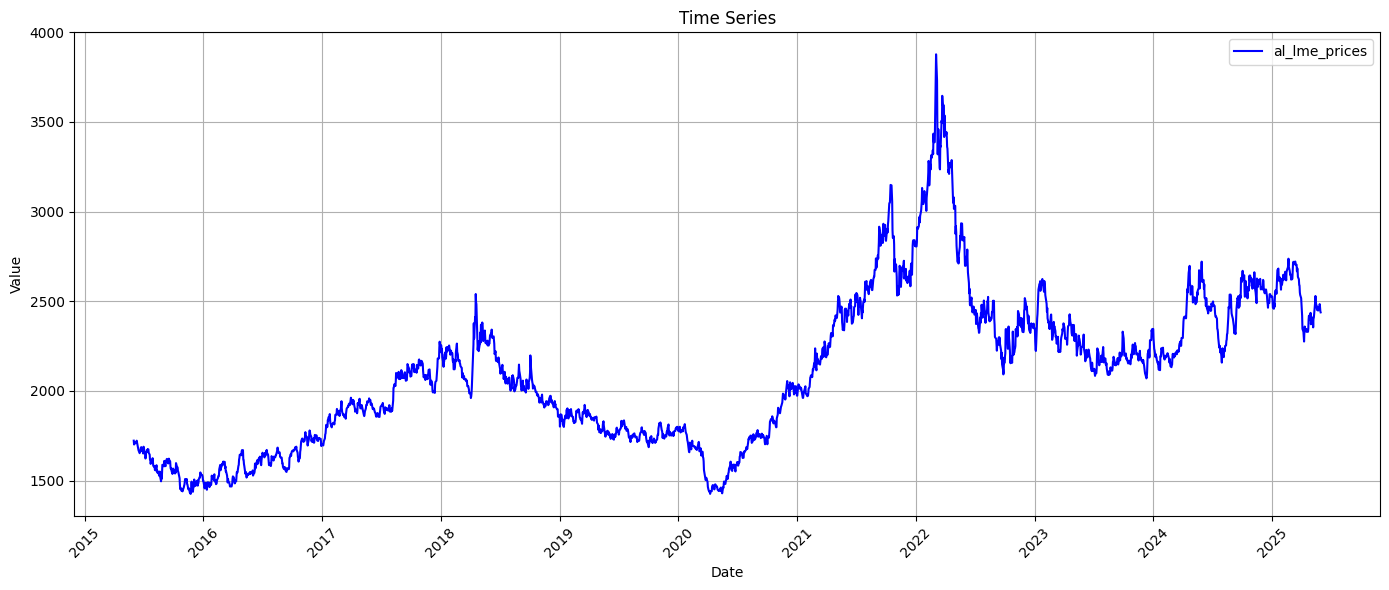

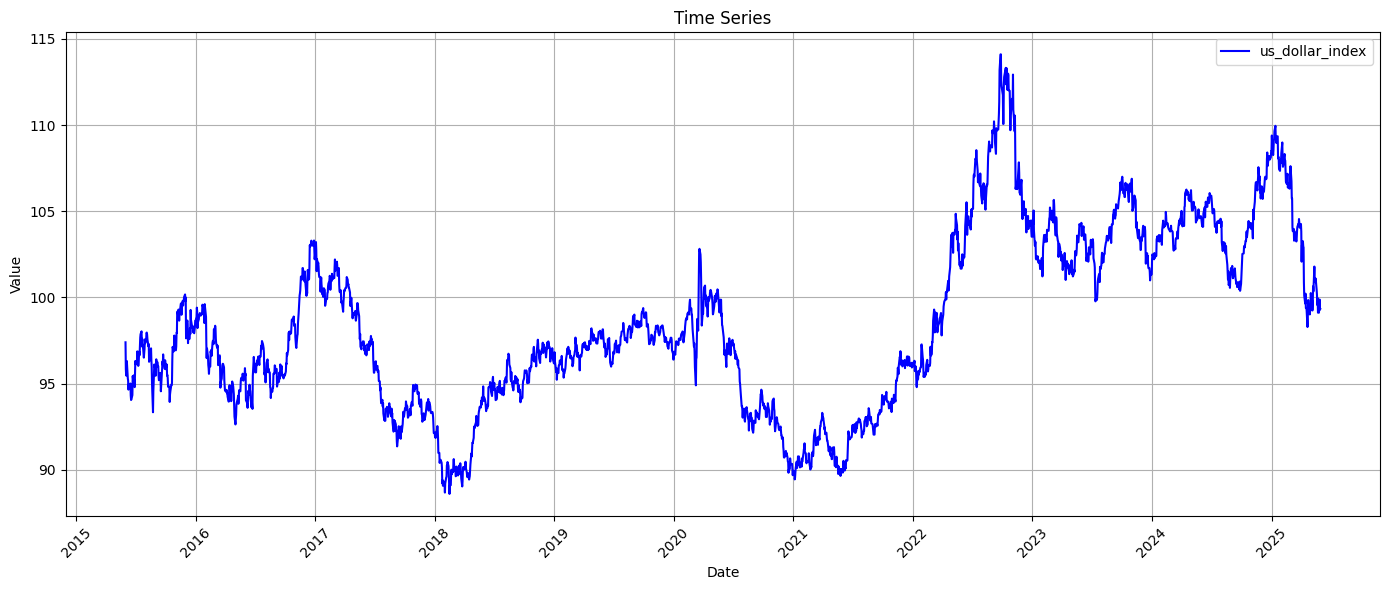

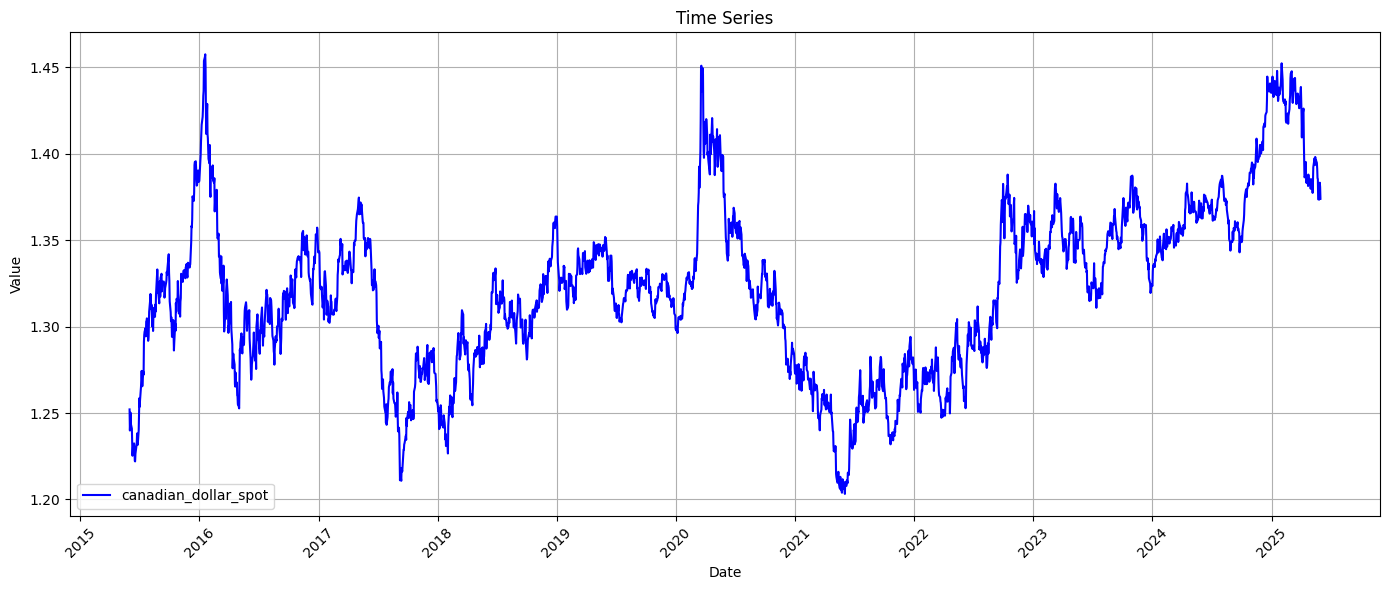

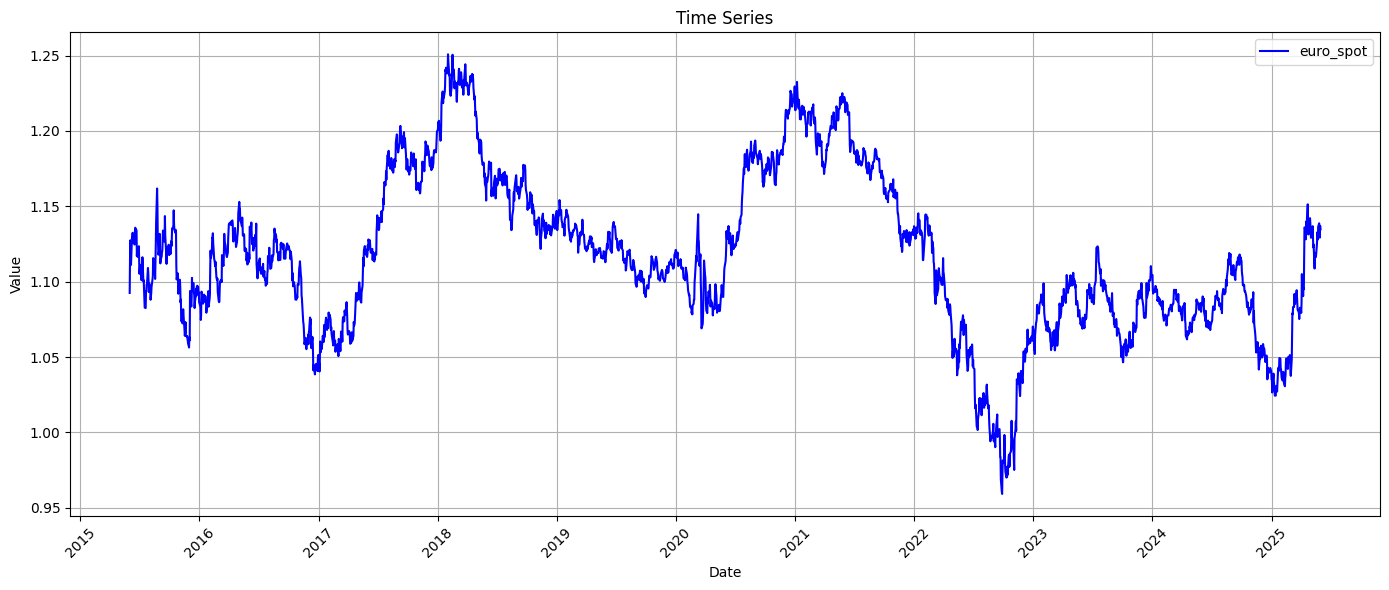

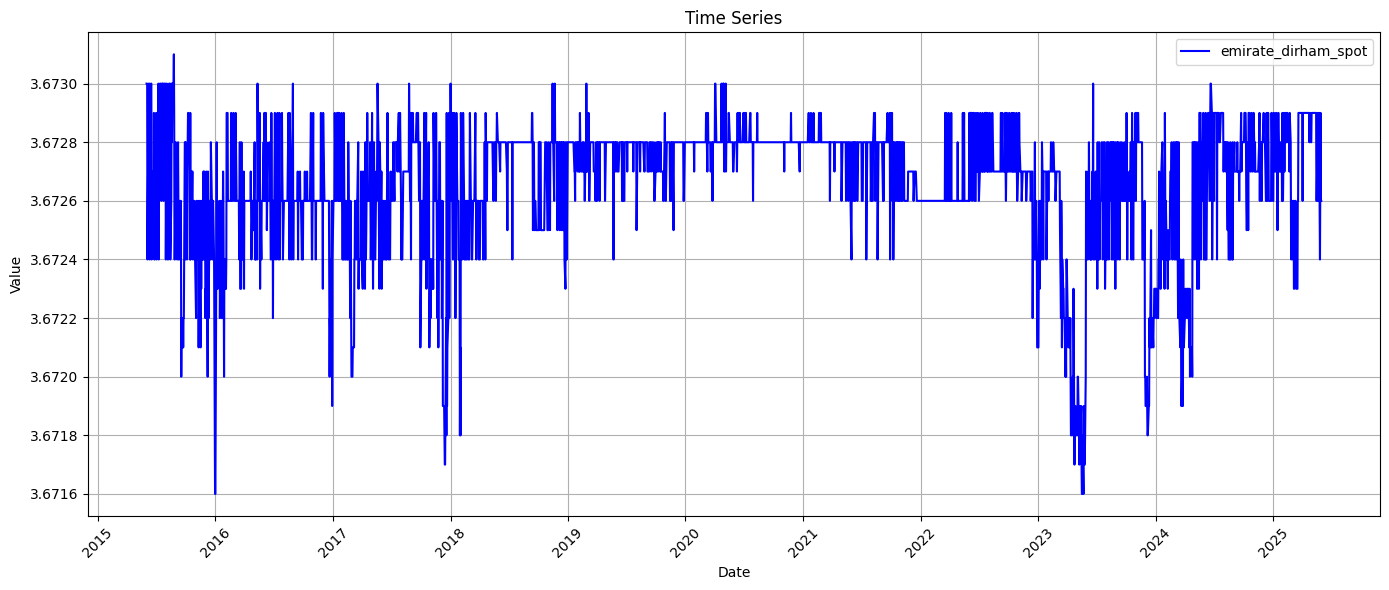

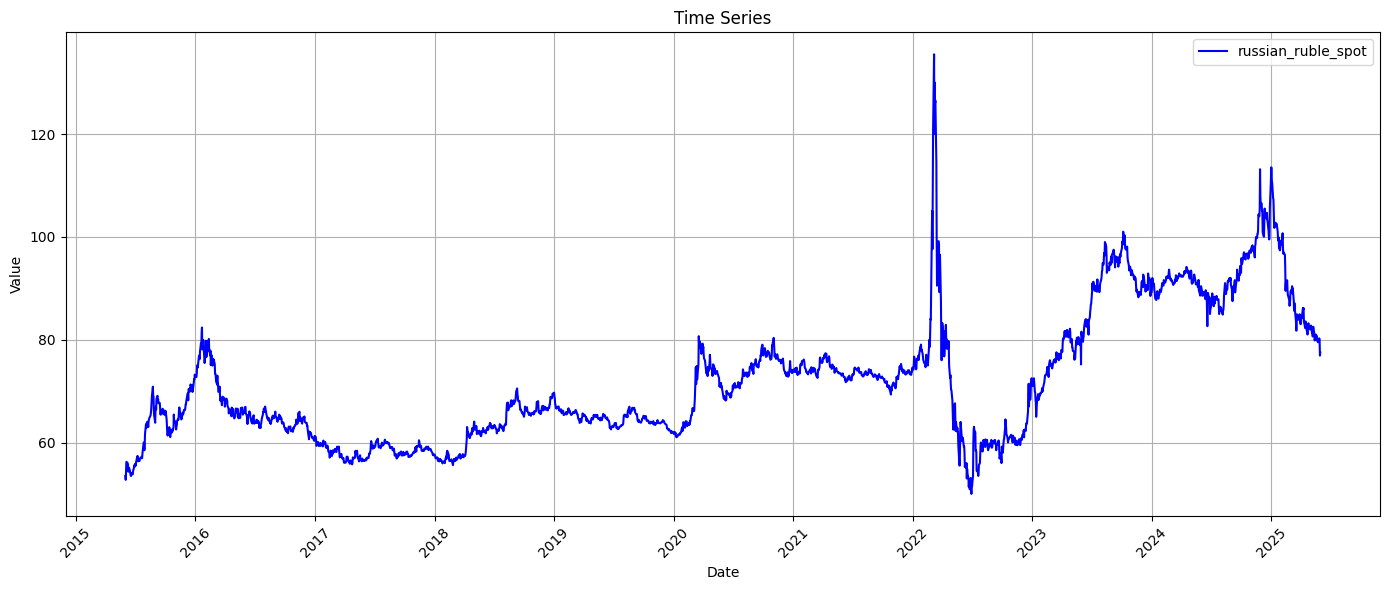

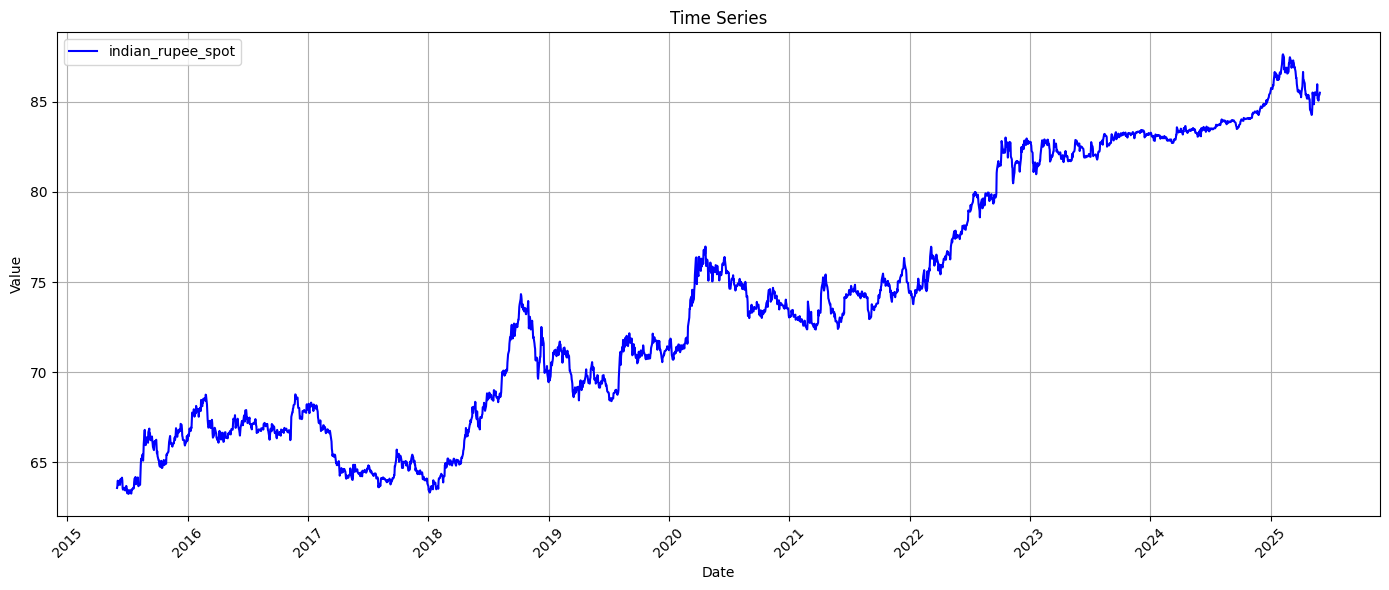

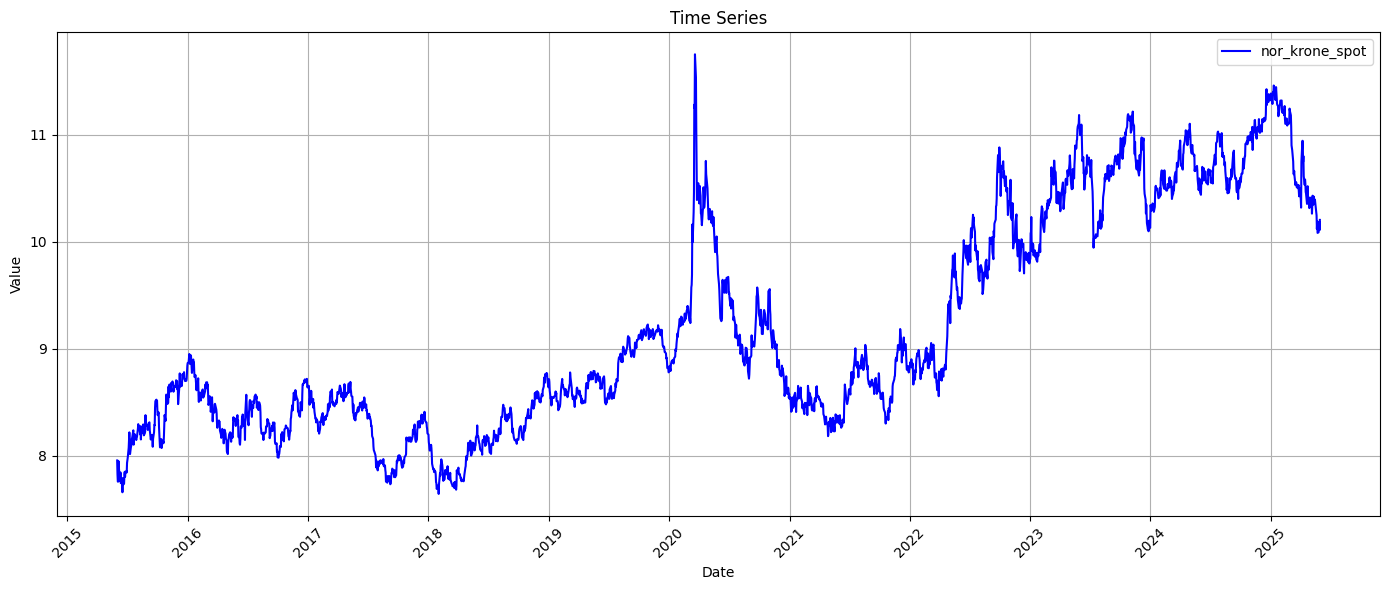

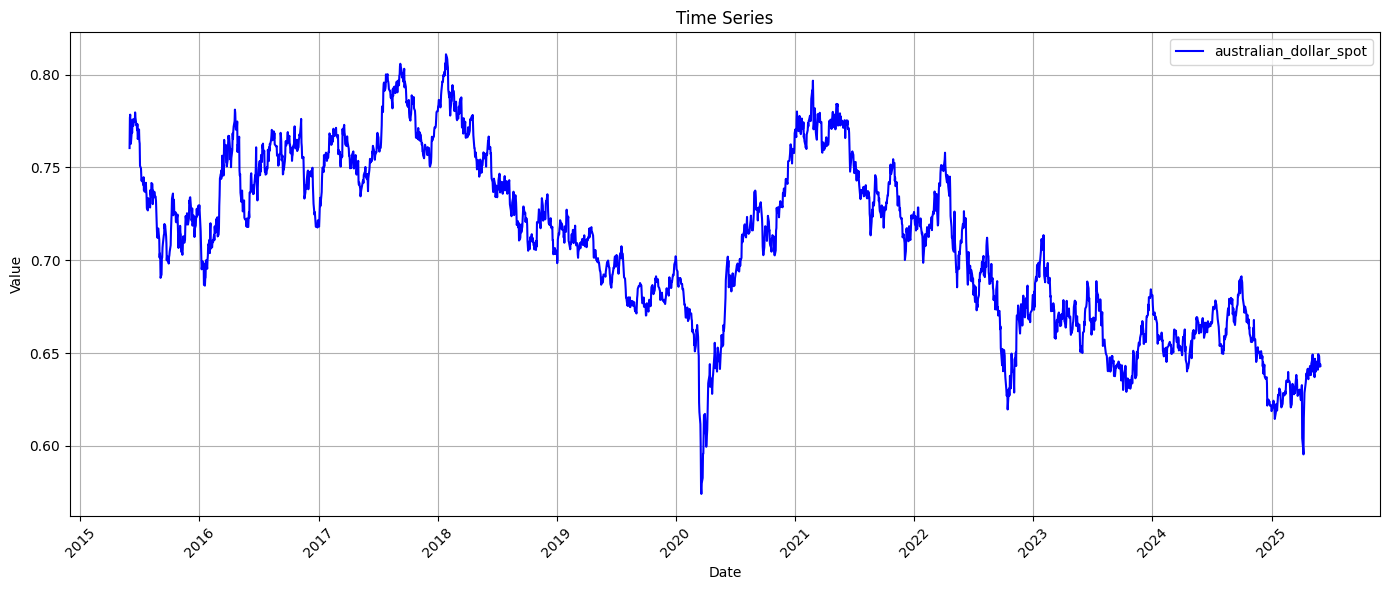

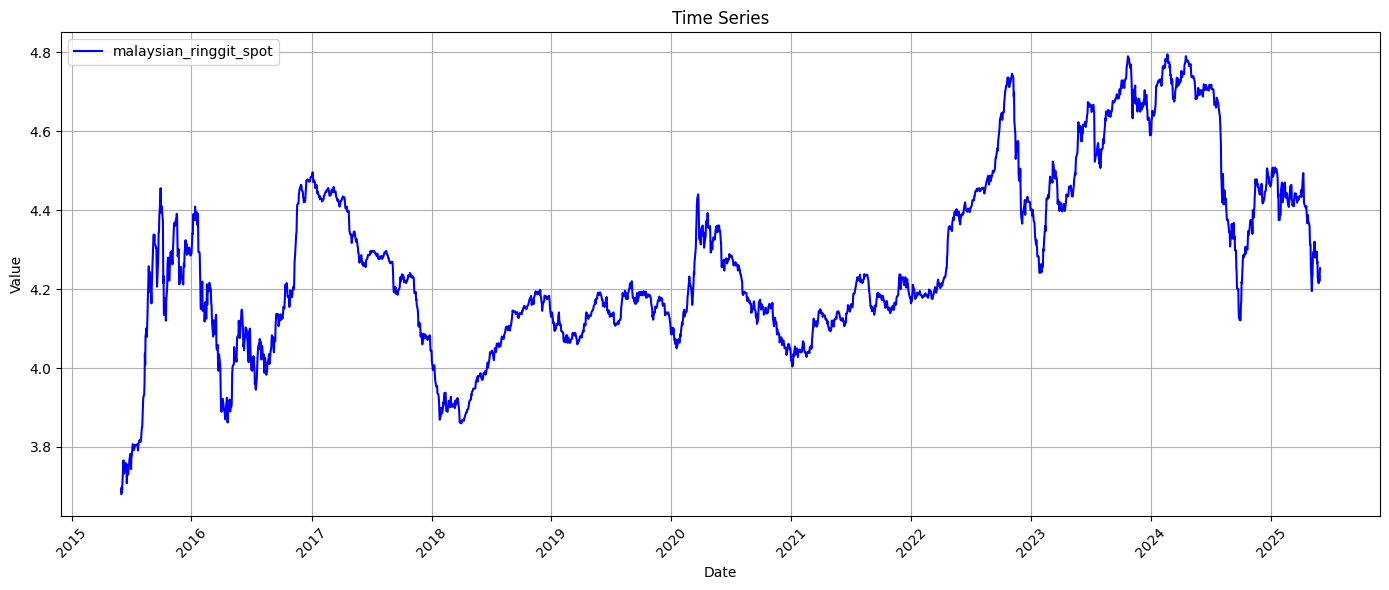

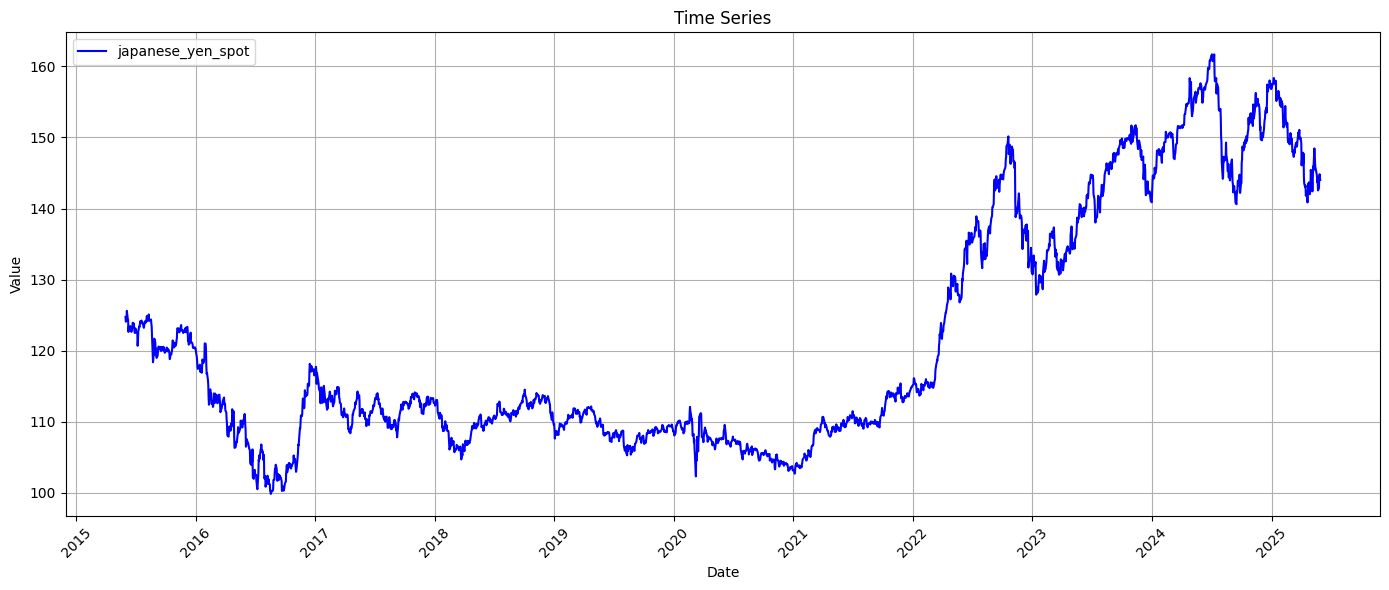

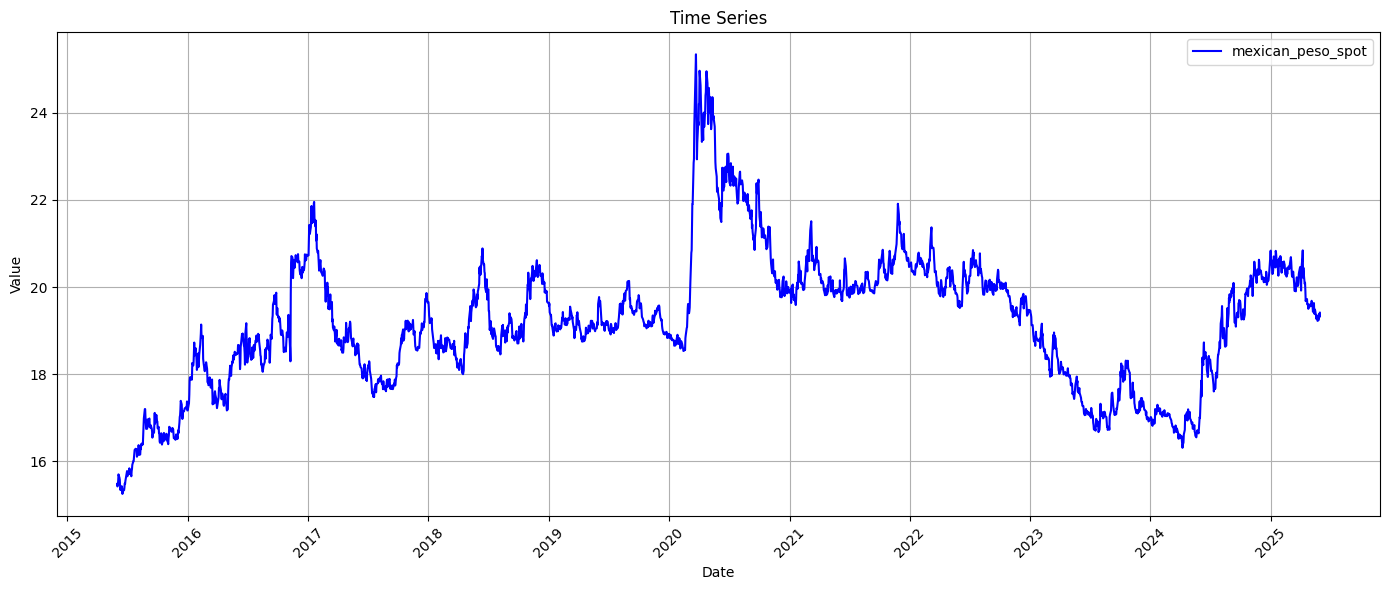

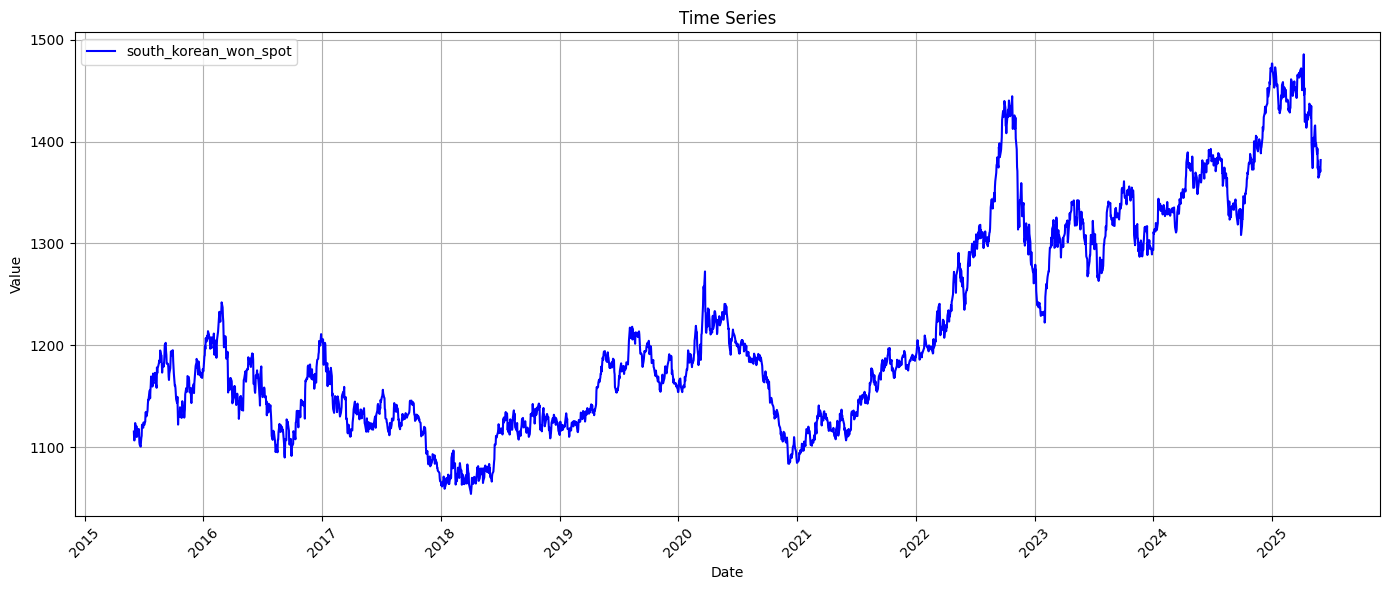

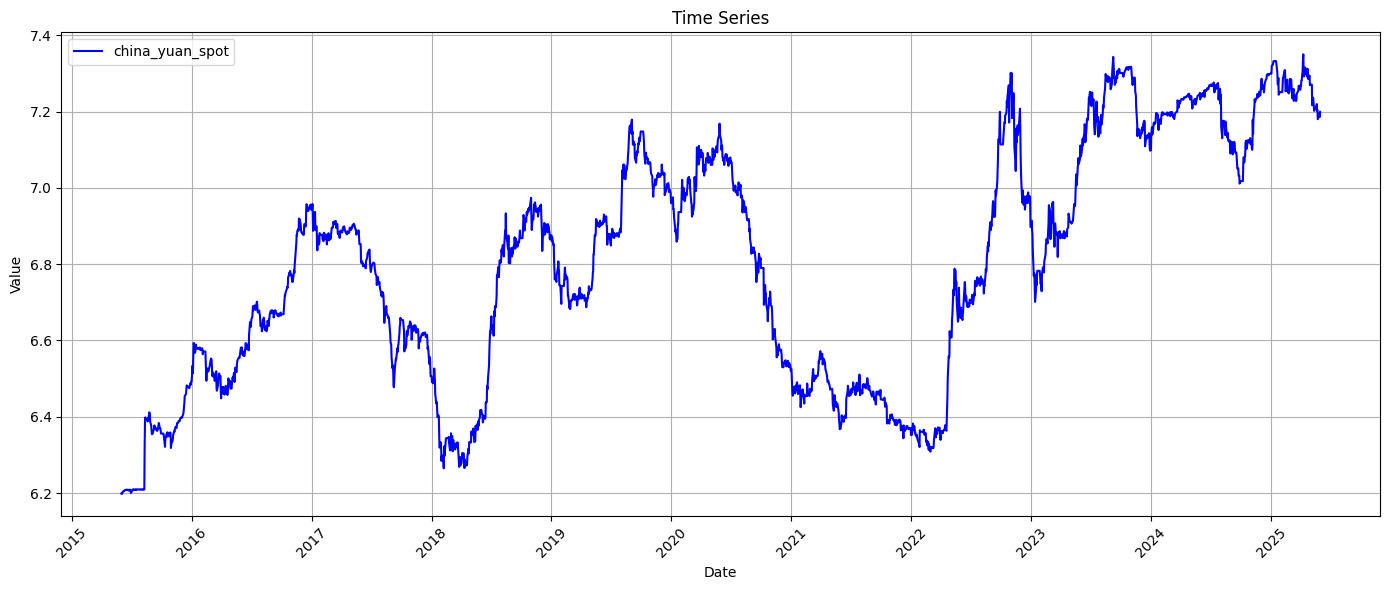

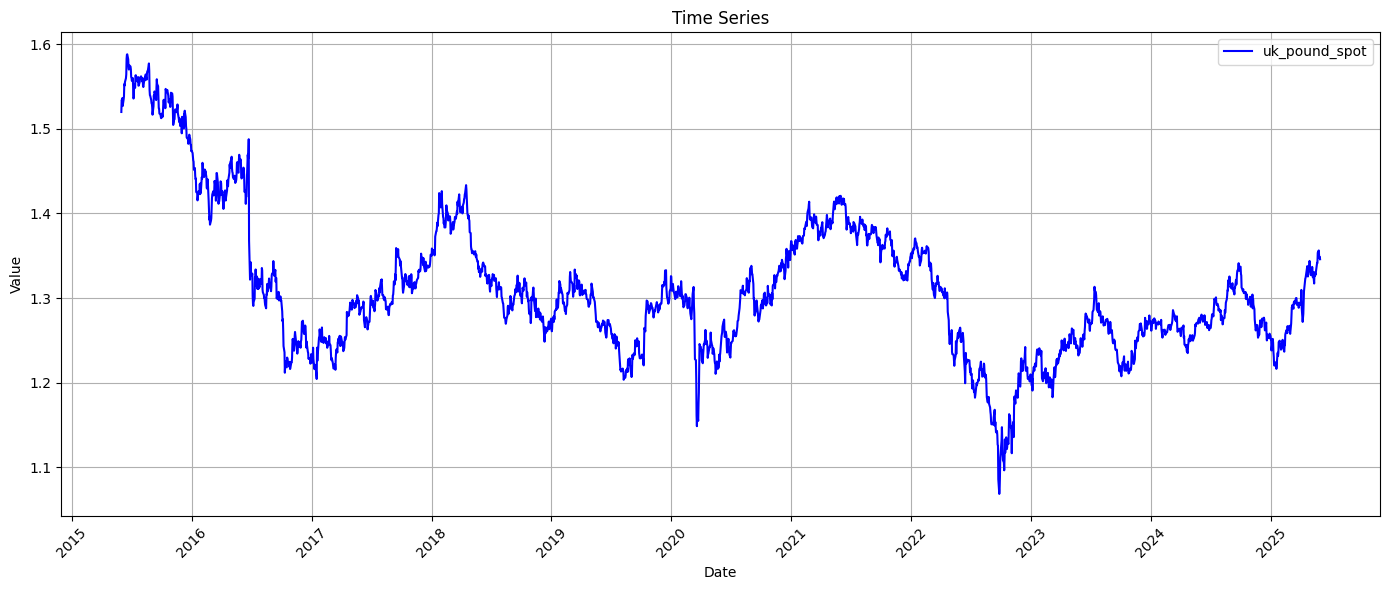

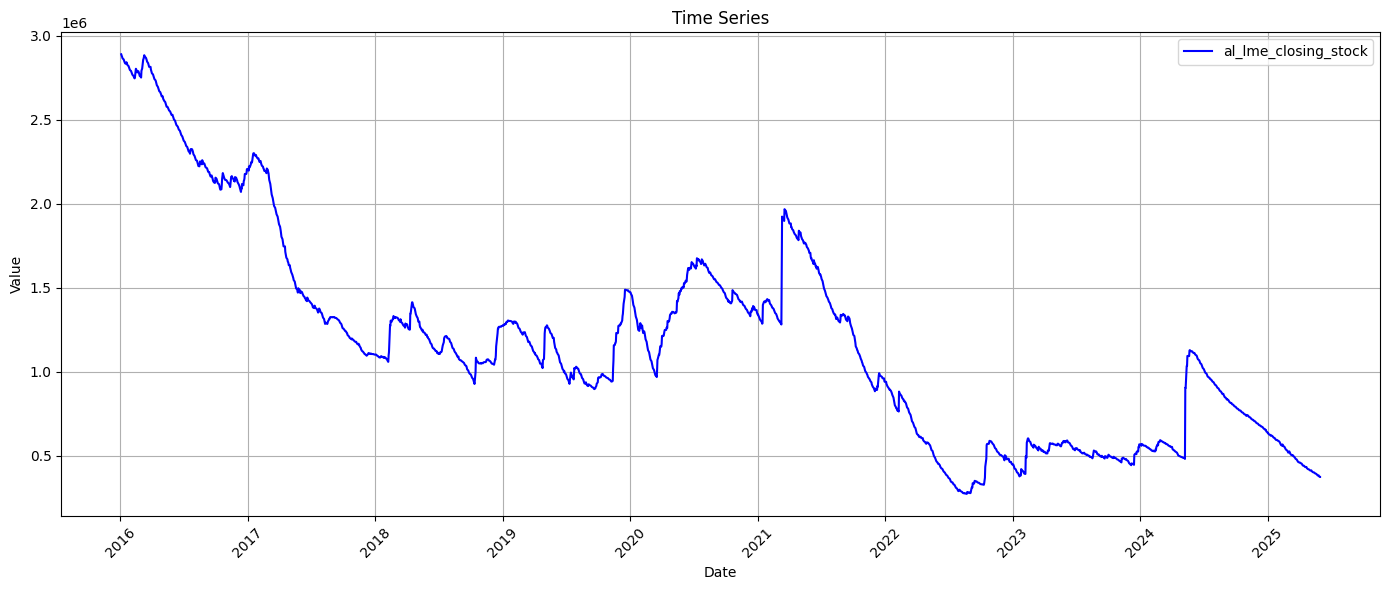

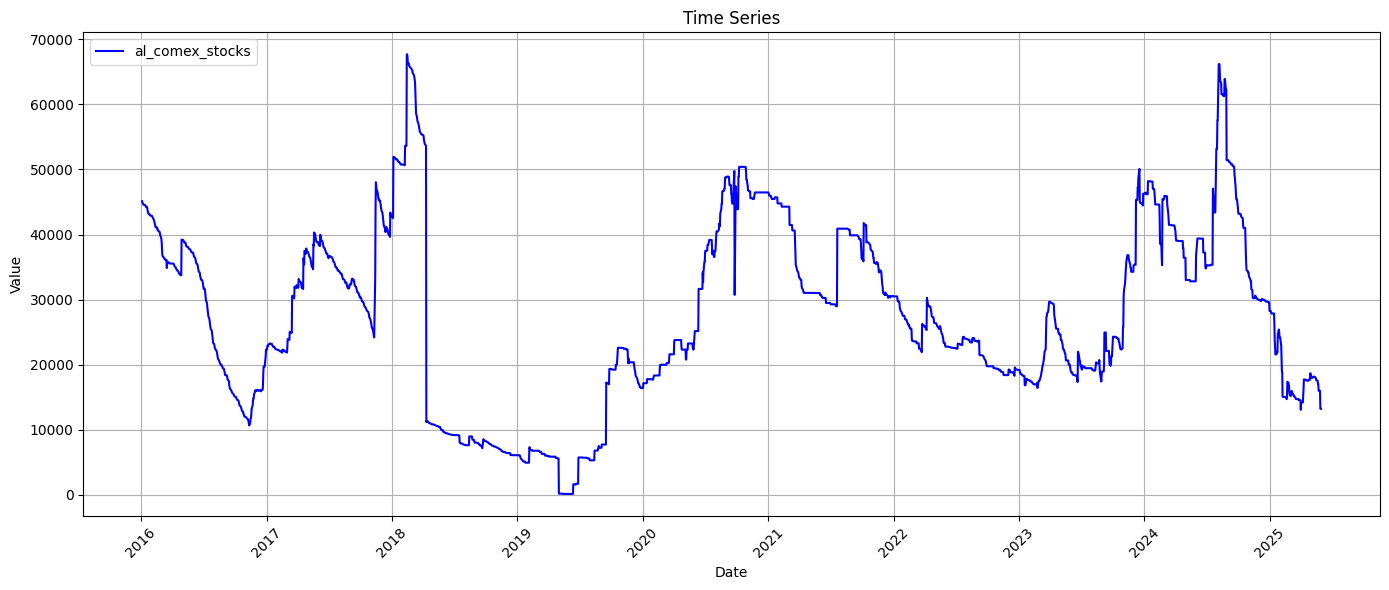

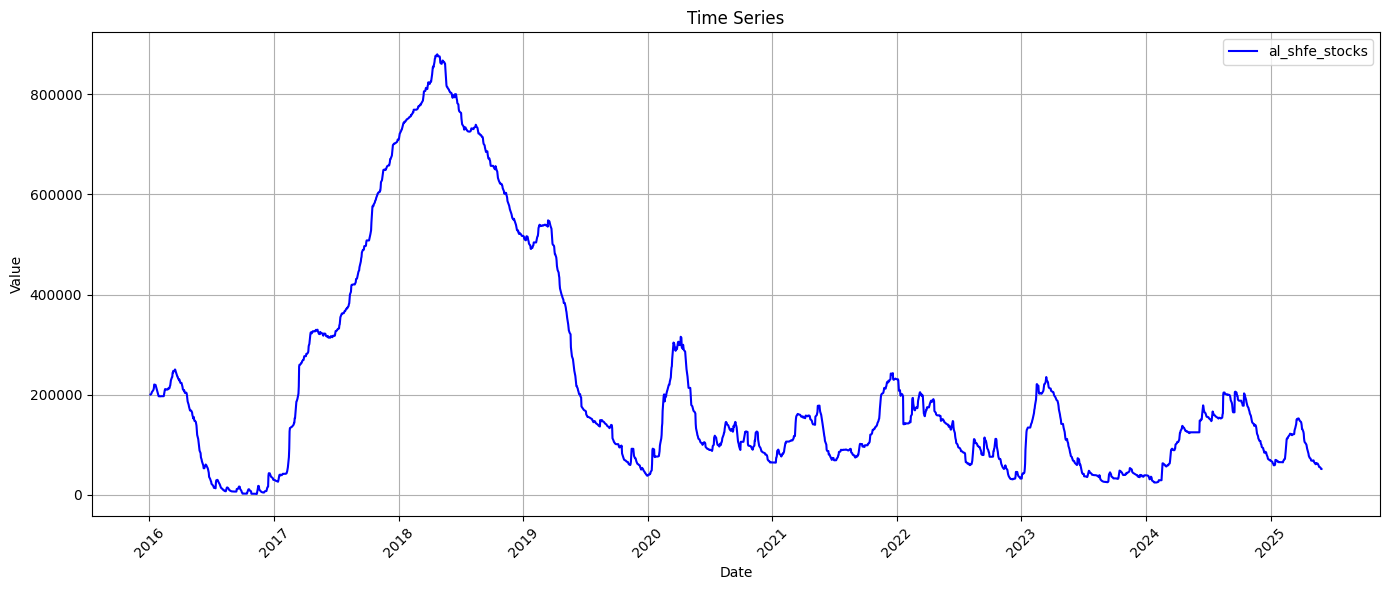

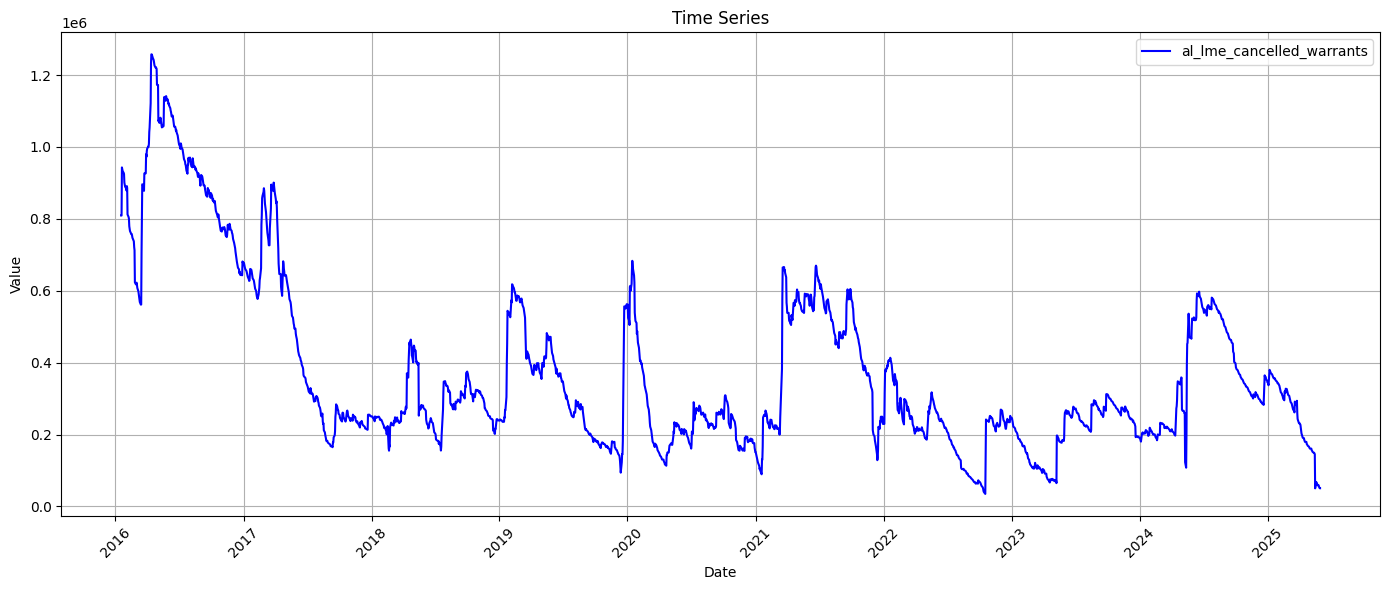

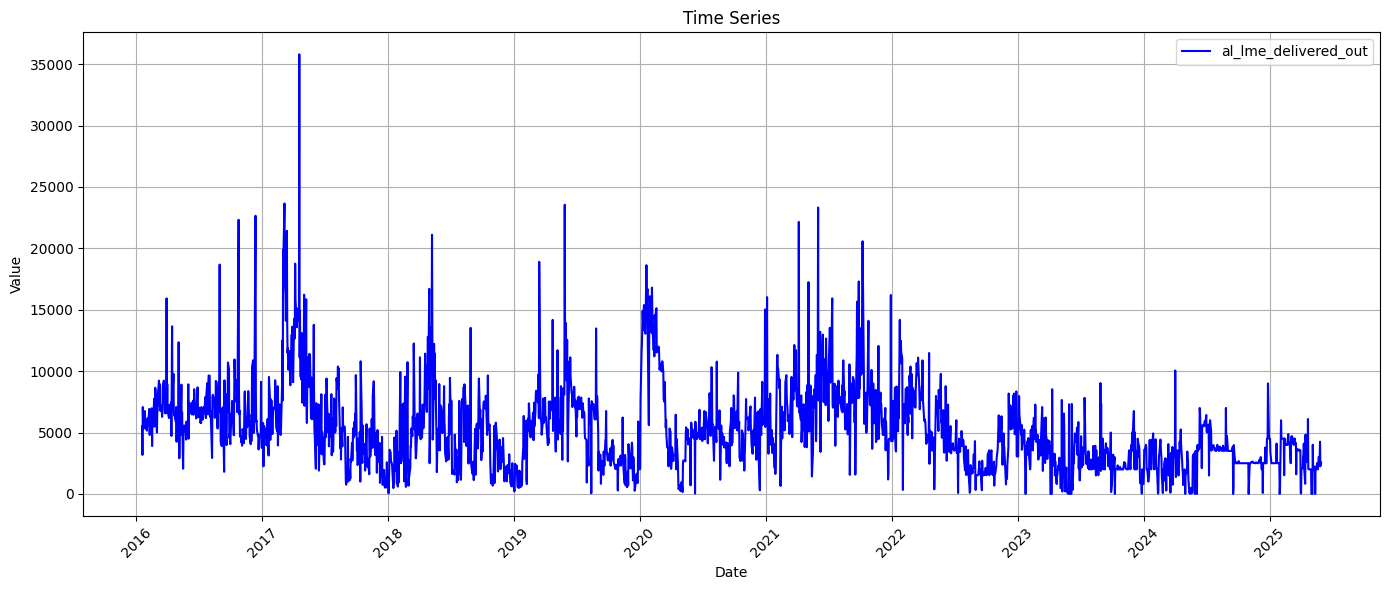

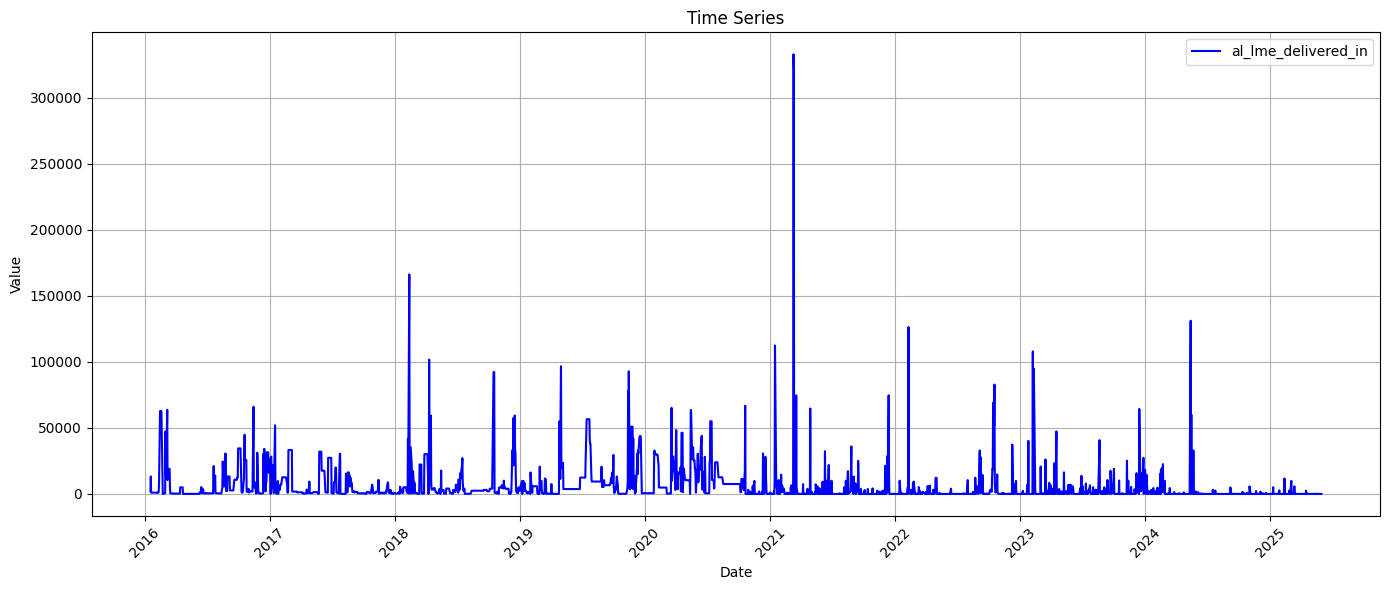

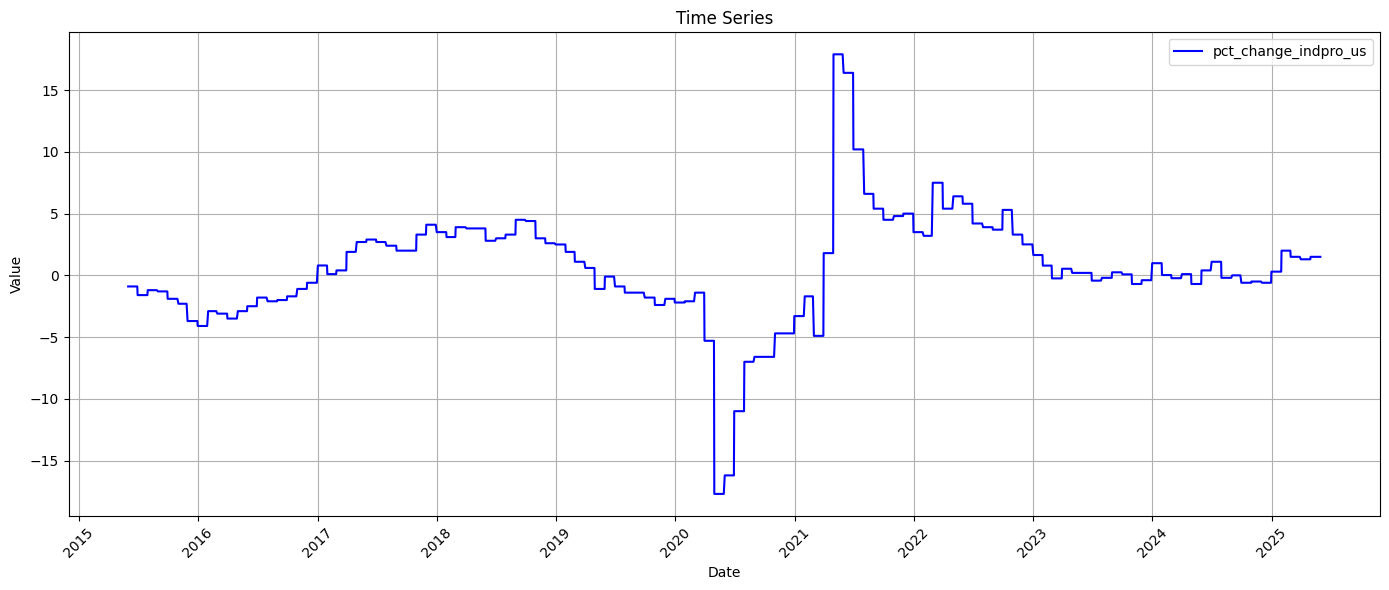

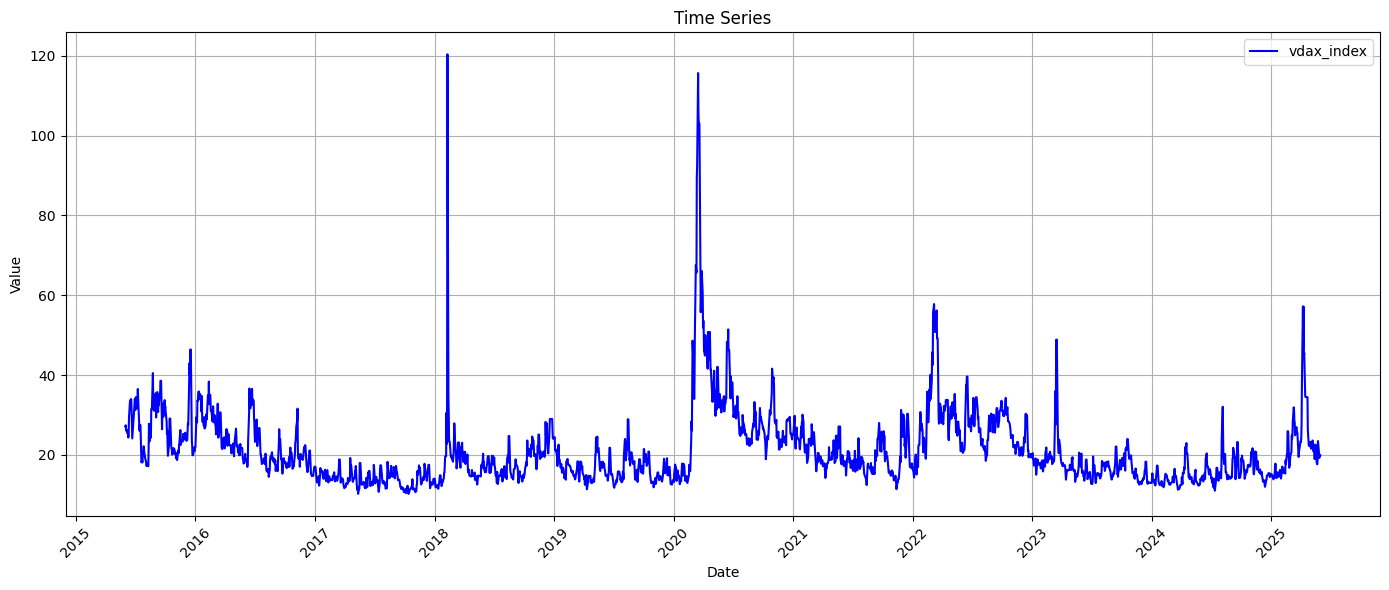

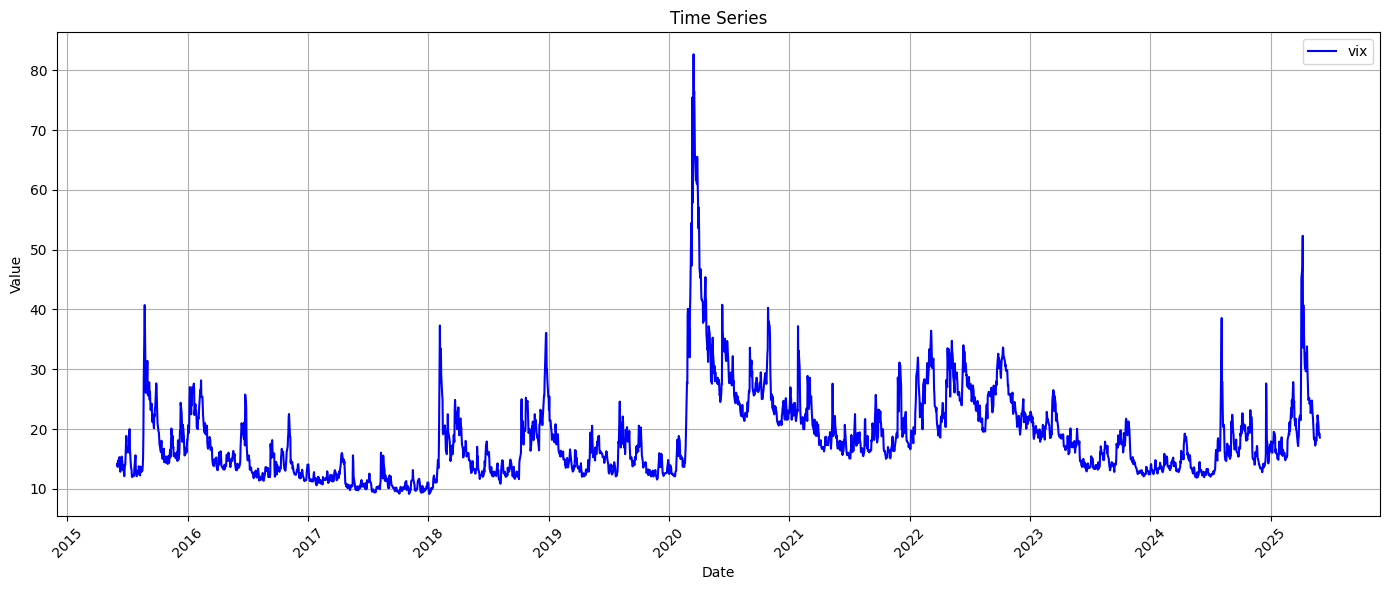

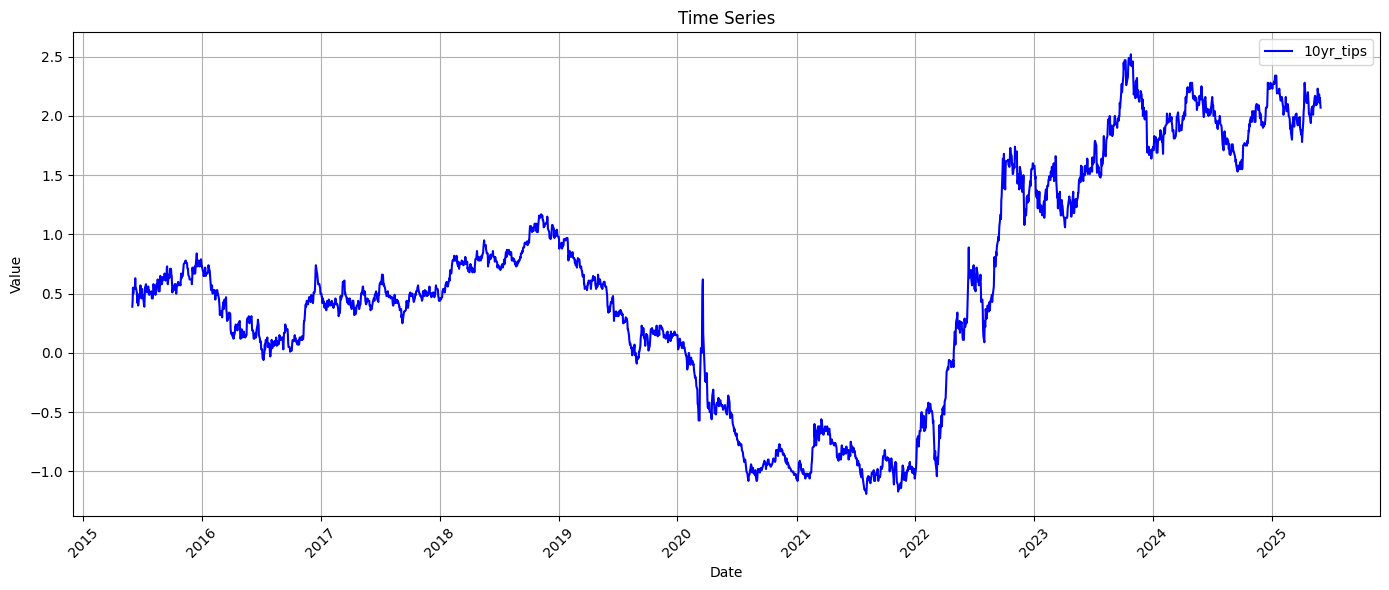

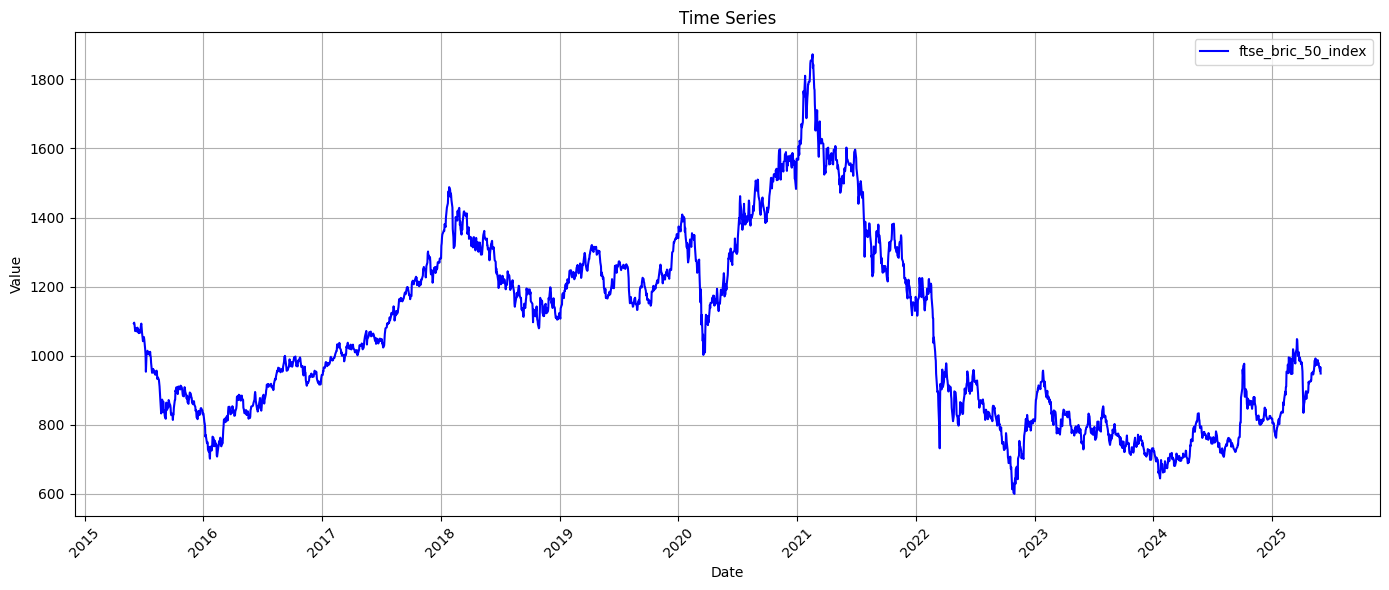

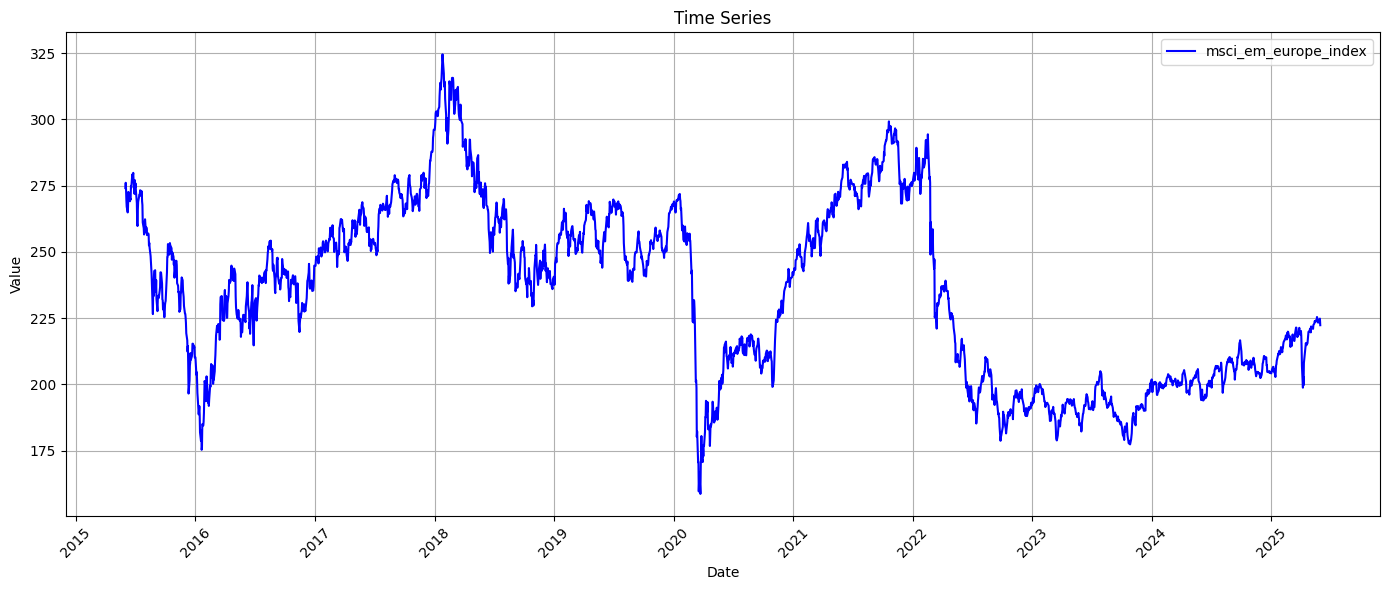

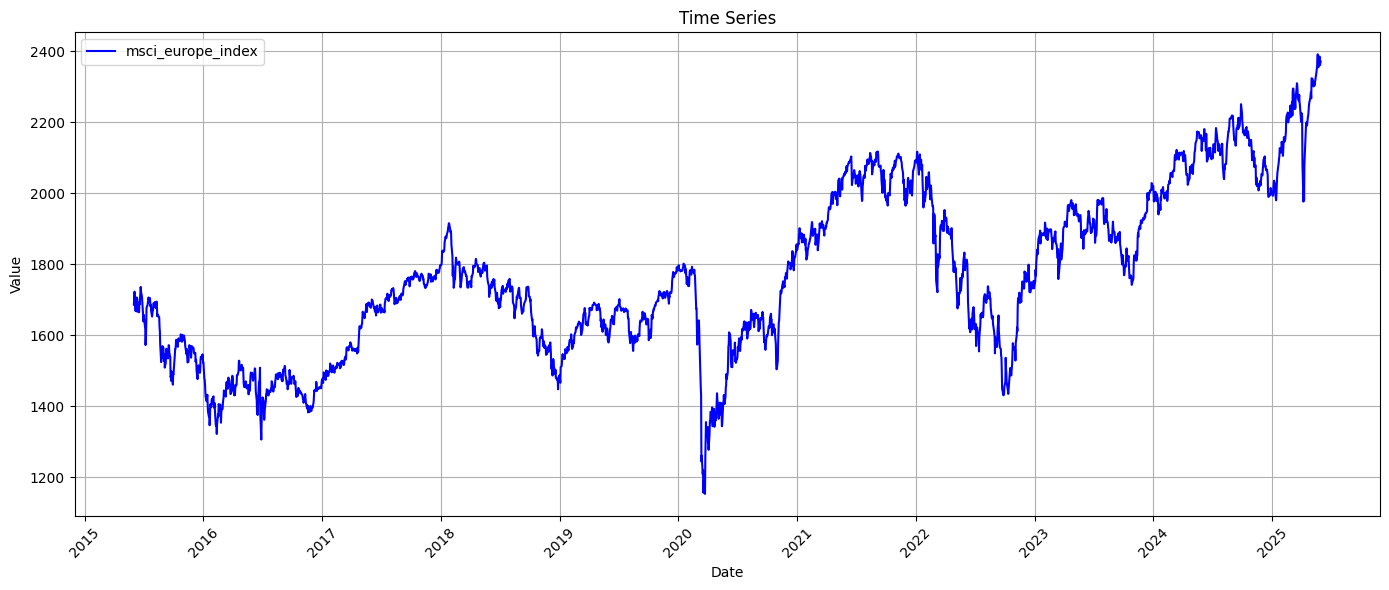

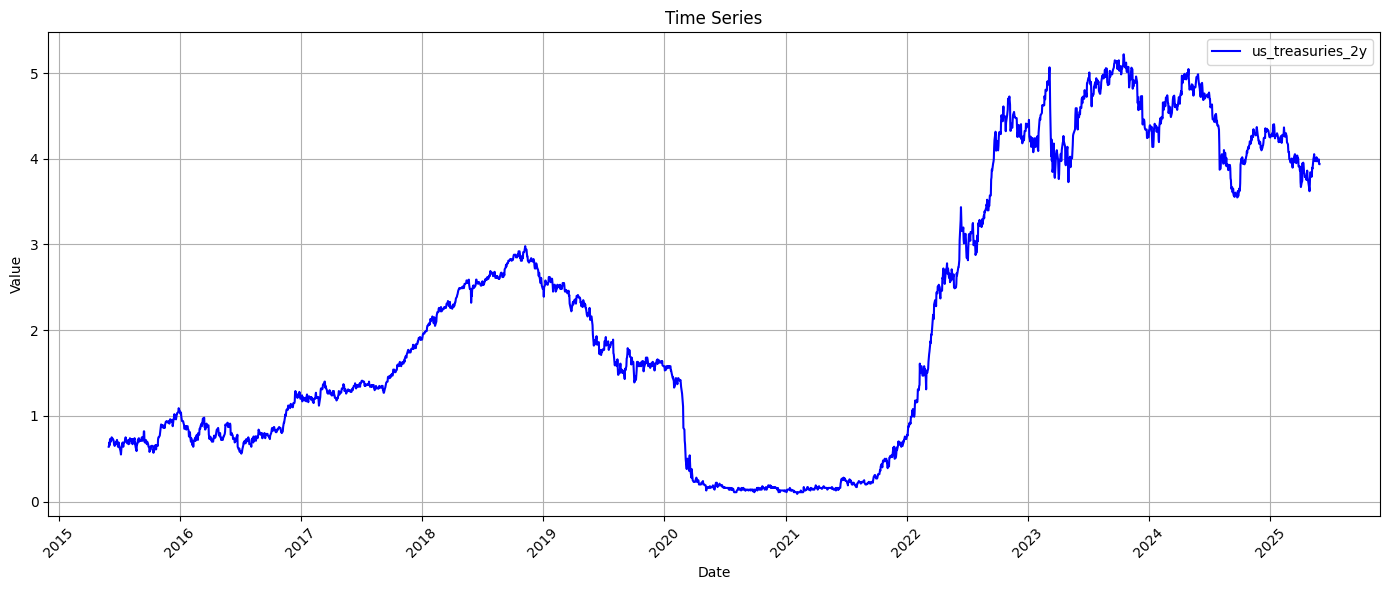

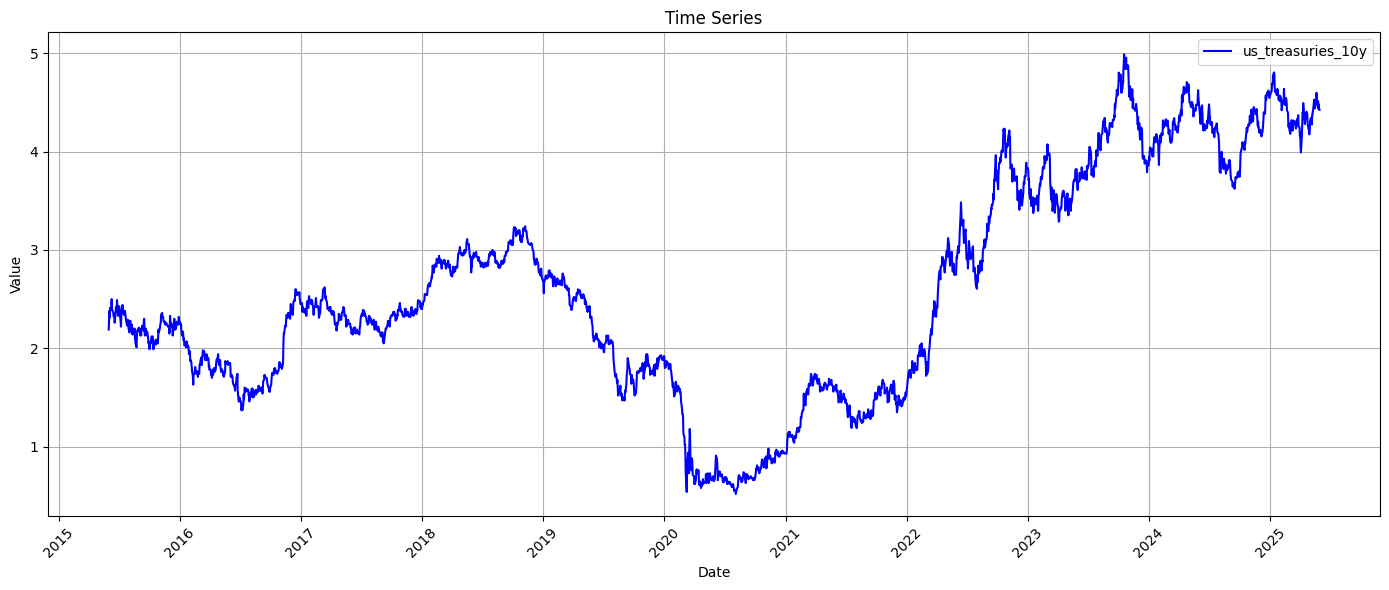

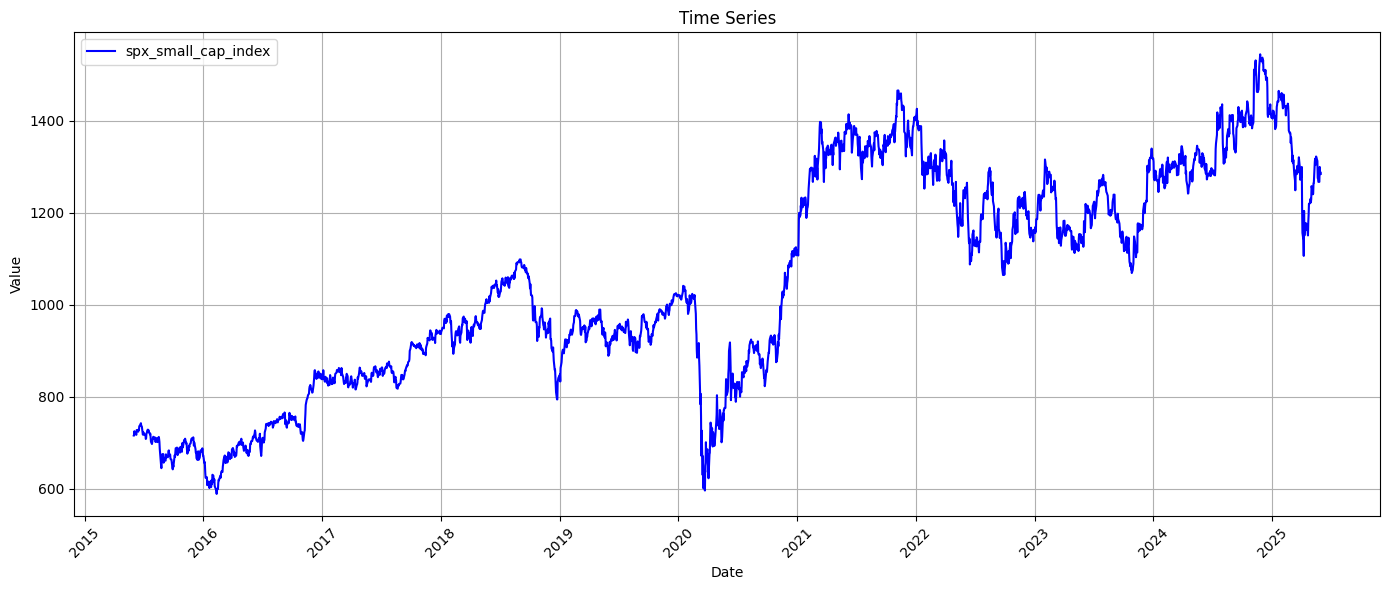

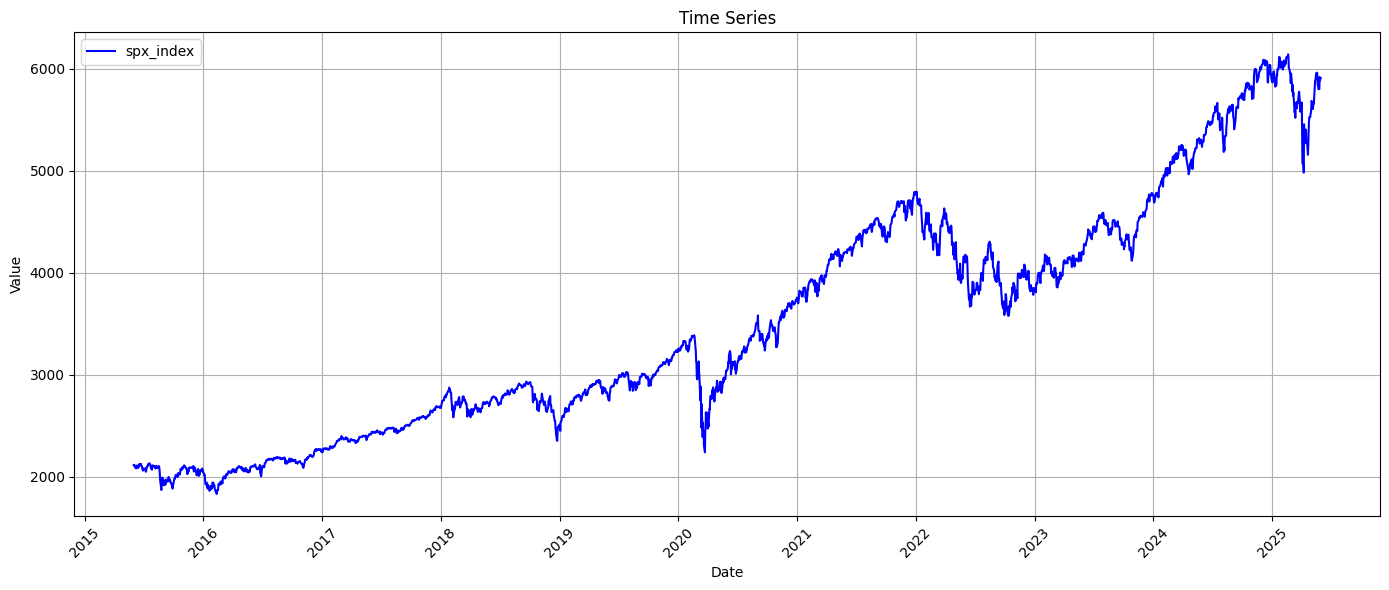

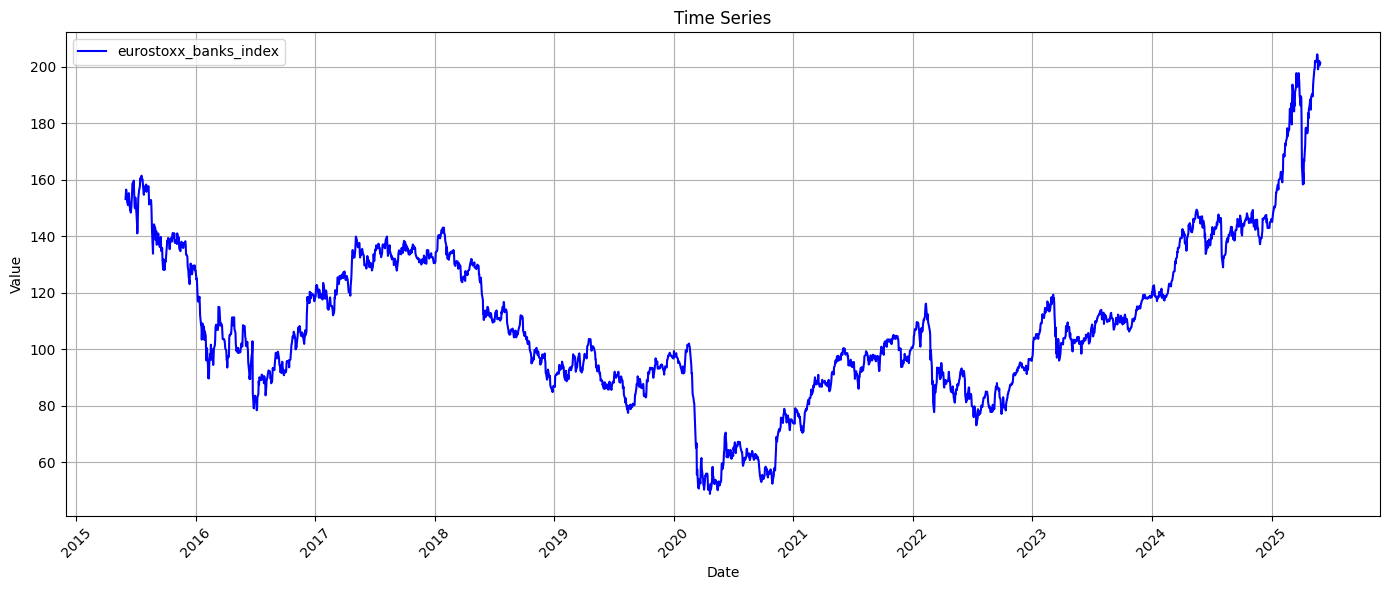

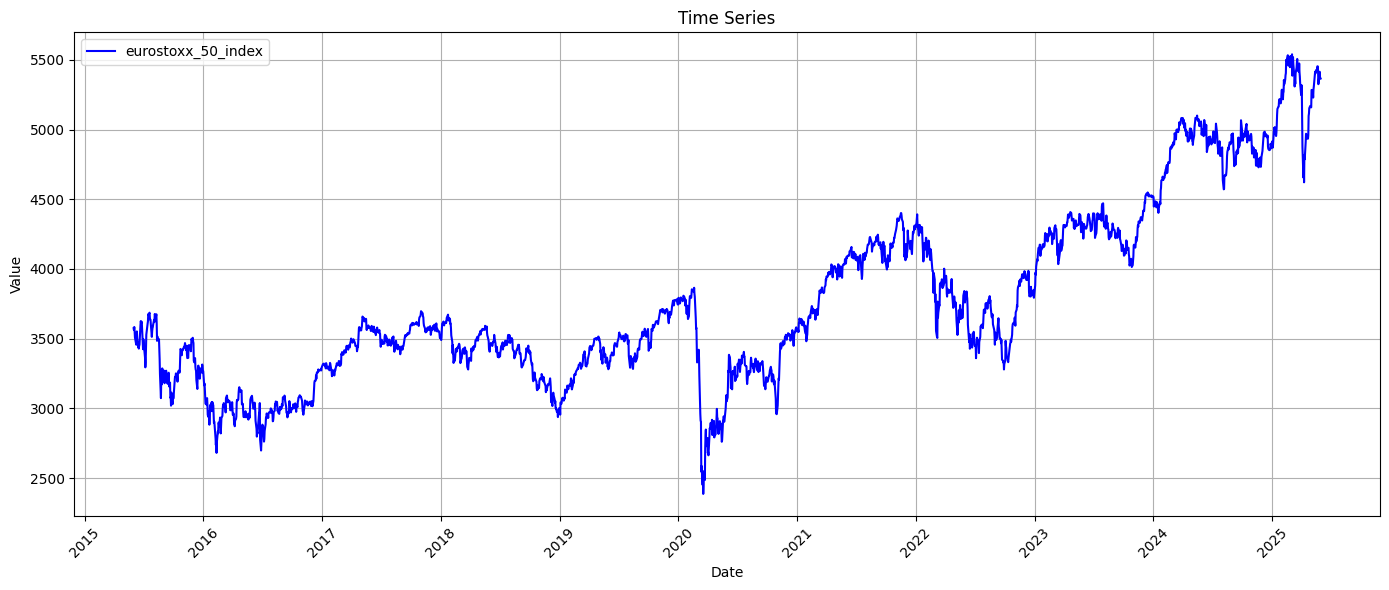

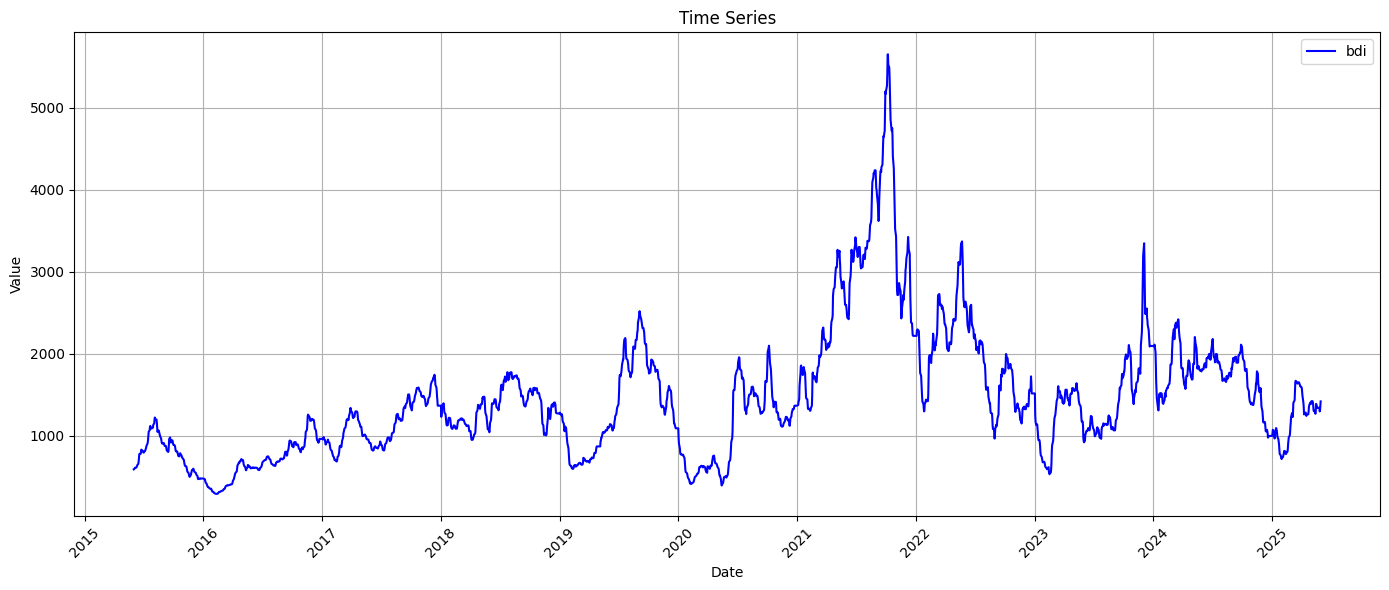

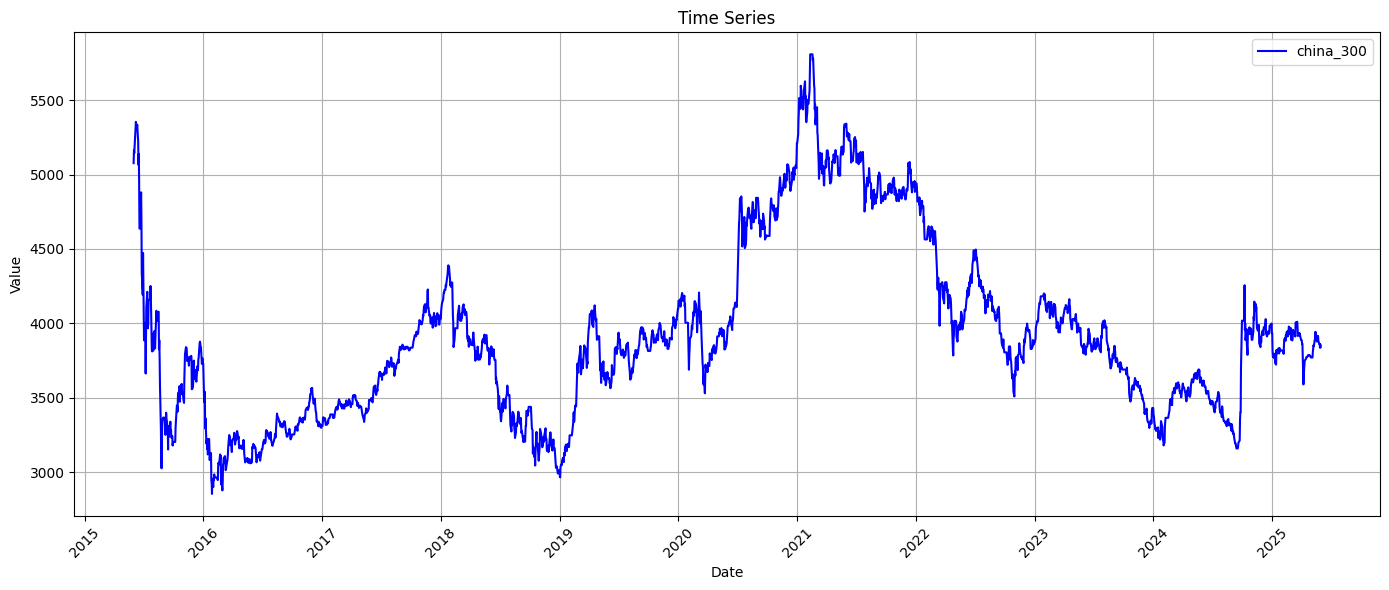

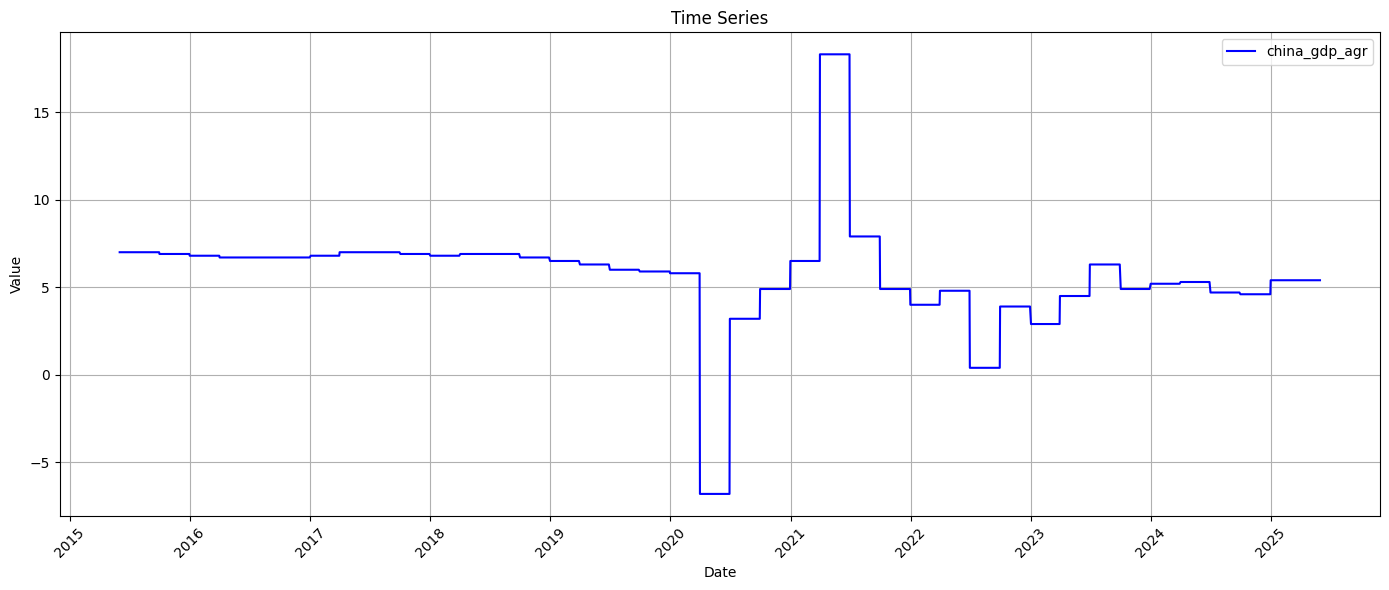

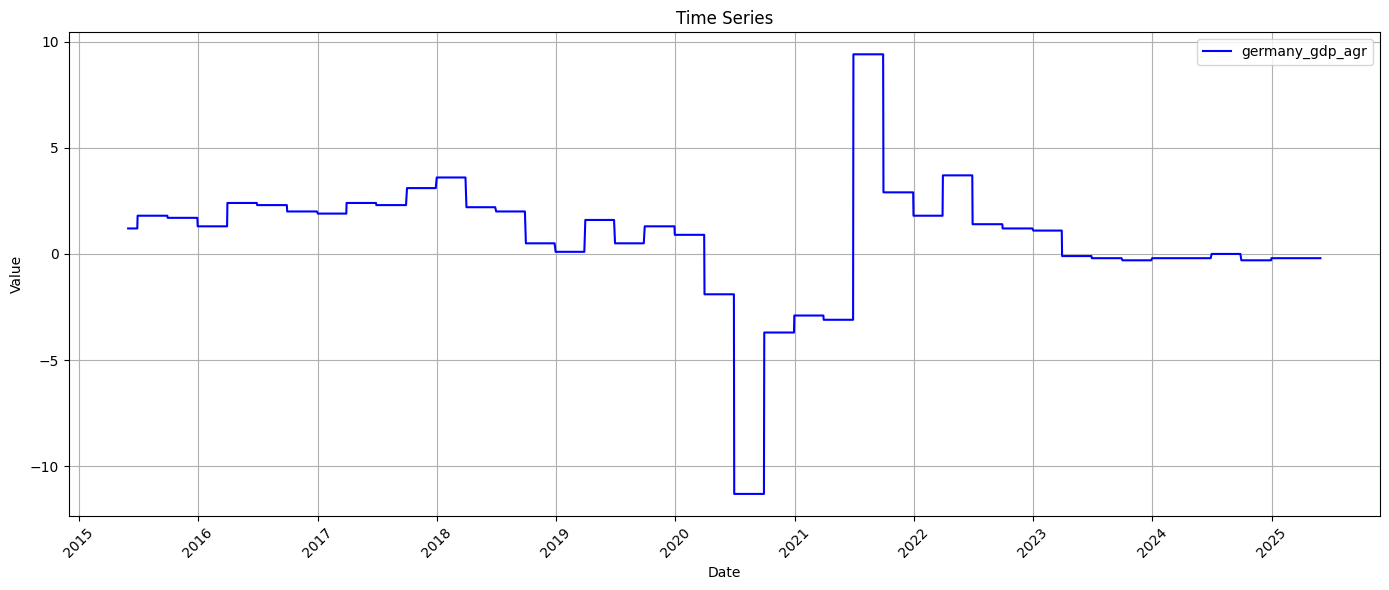

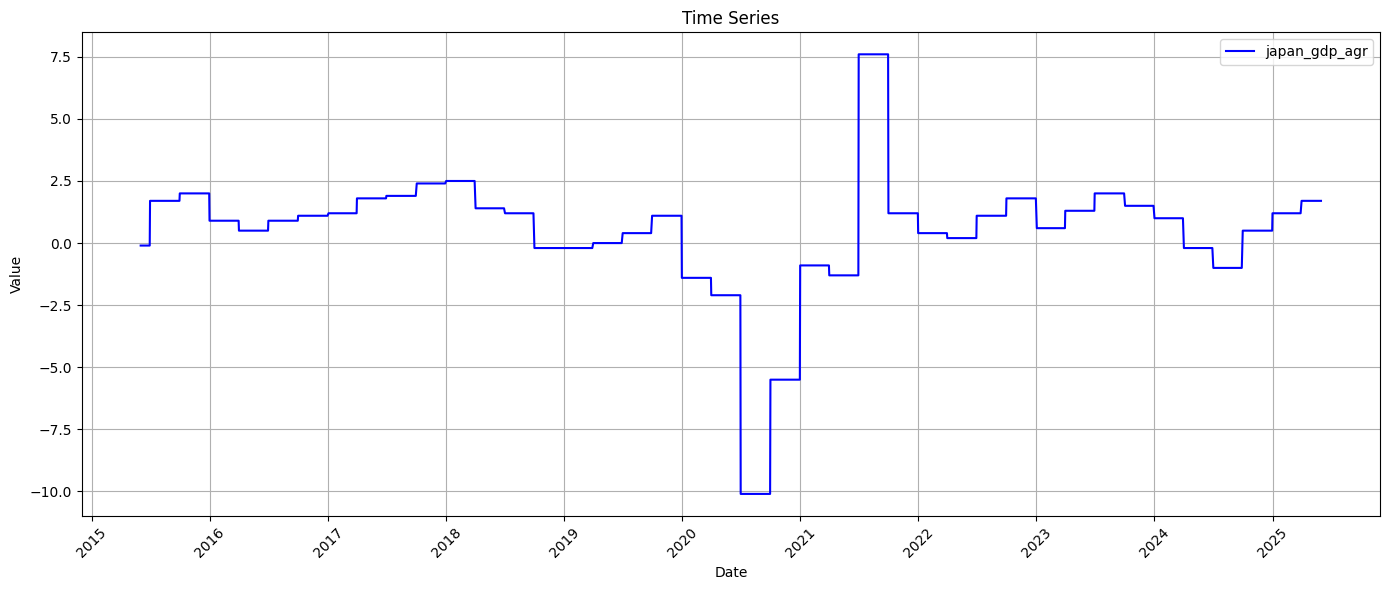

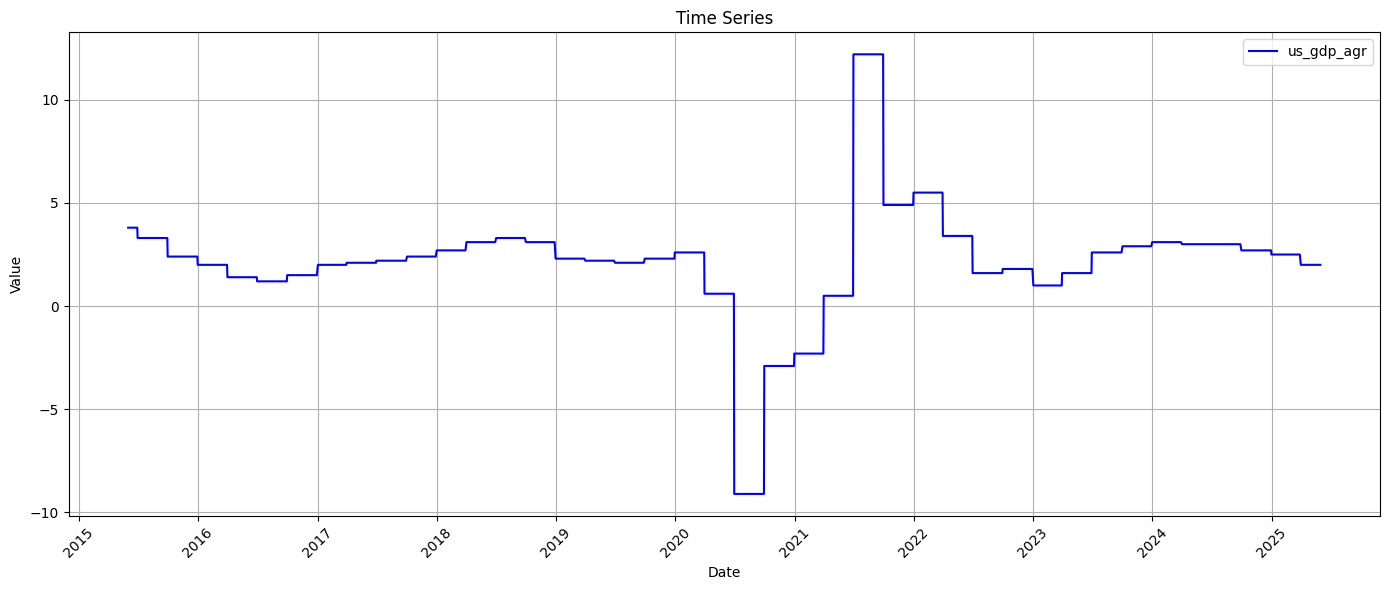

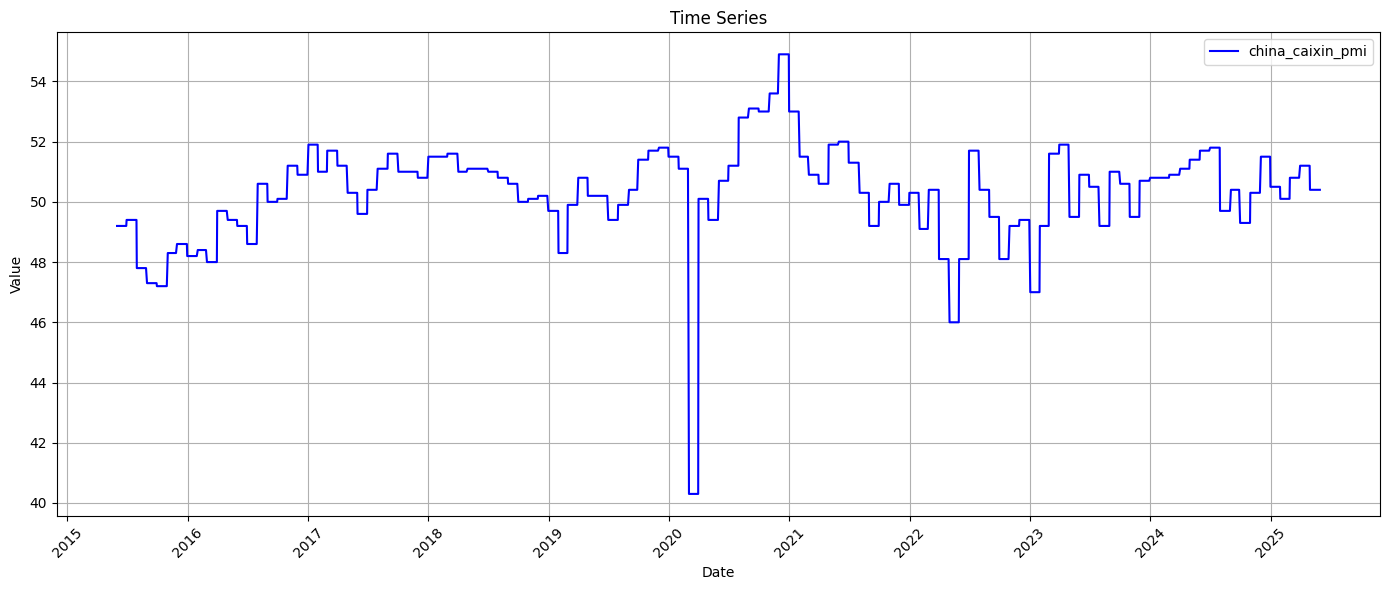

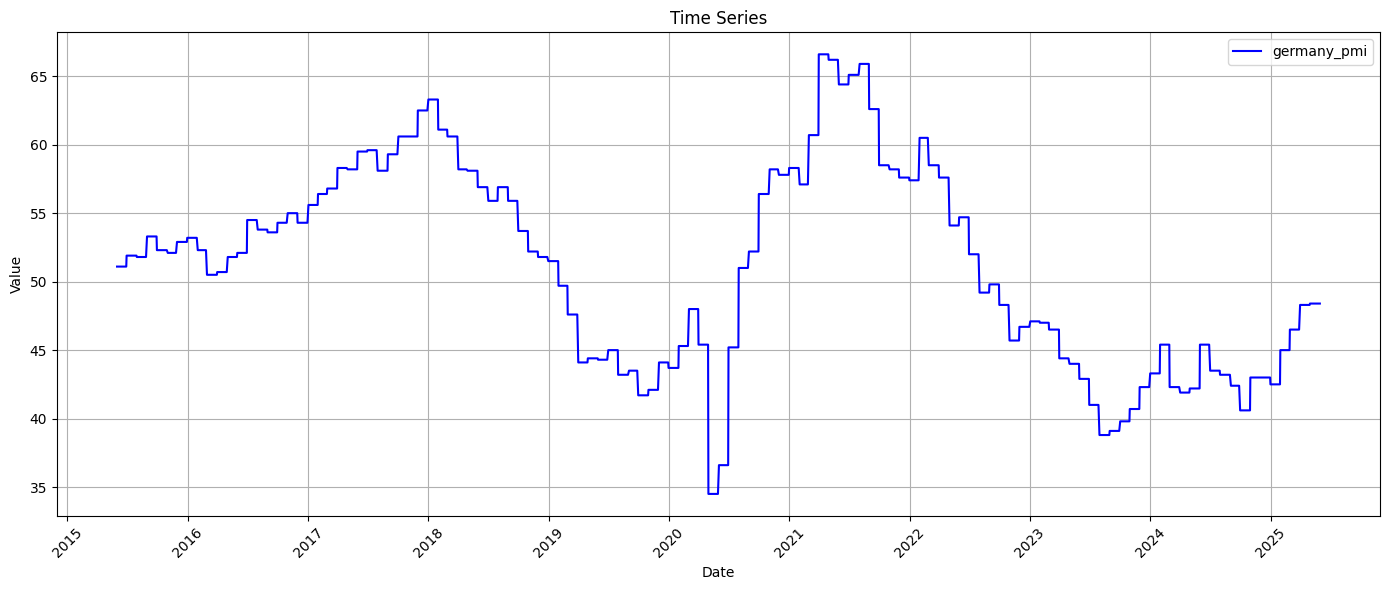

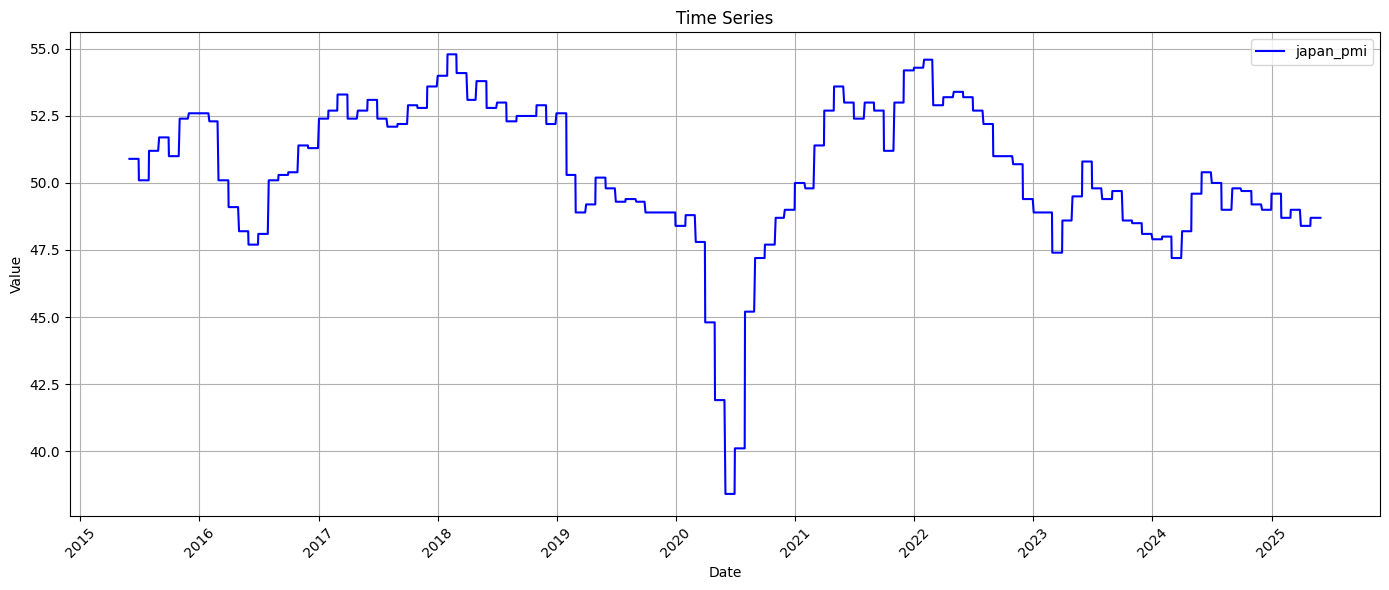

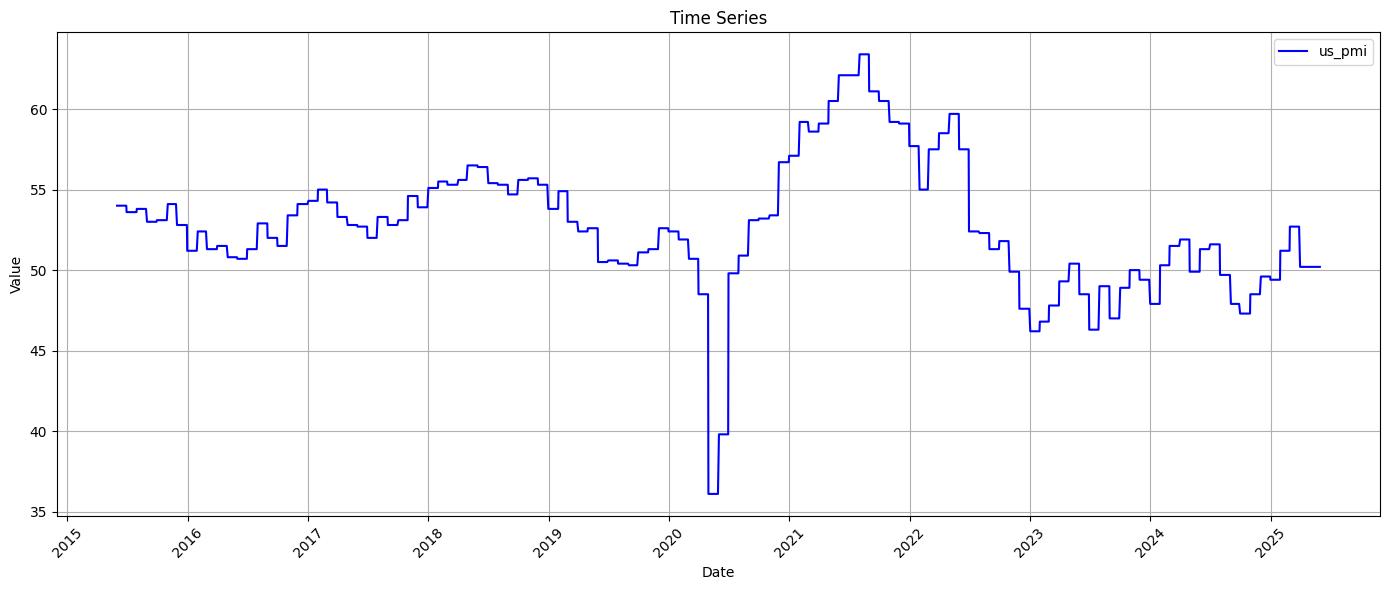

In [ ]:
for i, null_count in enumerate(df.isna().sum()):
    if i == 0: continue
    ax = line_plot(df['date'], df[df.columns[i]], df.columns[i], show=True)


<Axes: title={'center': 'Time Series'}, xlabel='Date', ylabel='Value'>

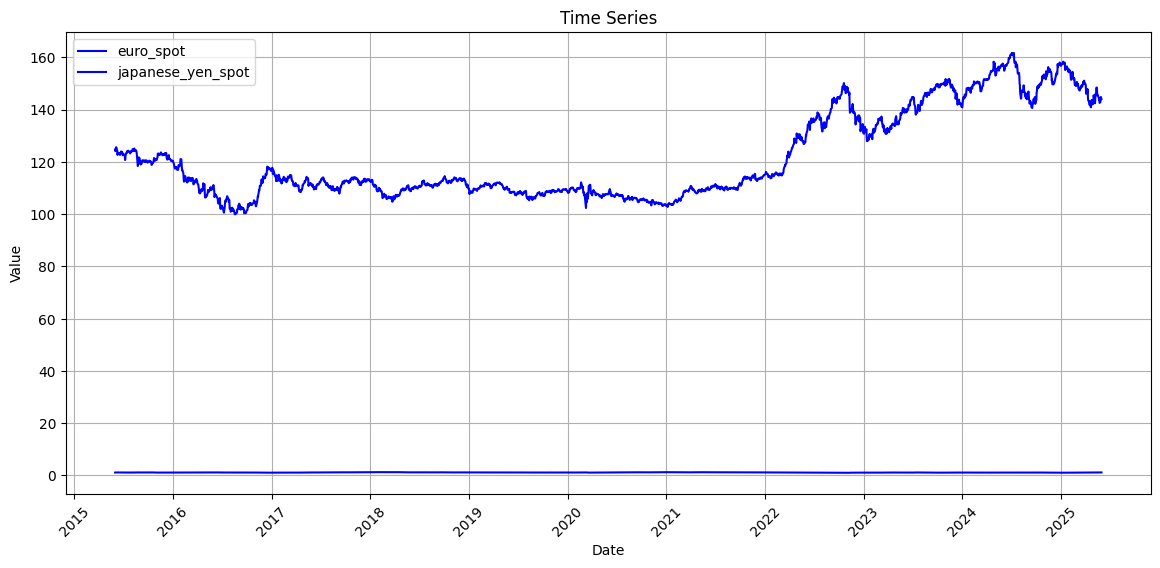

In [ ]:
i = 4
ax = line_plot(df['date'], df[df.columns[i]], df.columns[i], show=False)

i = 11
line_plot(df['date'], df[df.columns[i]], df.columns[i], ax=ax, show=True)